# AI Exposure and Labor Market Displacement Across U.S. Occupations

**Author:** Ryan Xian | University of Toronto | HBSc Statistics & Economics (Data Analytics Focus)


## Research Questions

1. Which occupations, industries, and metro areas face the highest AI displacement risk?
2. How does AI exposure correlate with current wage levels, employment concentration, and educational requirements?
3. Are there demographic dimensions (e.g., gender-dominated occupations) where AI exposure is disproportionately concentrated?
4. What does the relationship between AI exposure and 2019–2024 employment changes suggest? Are high-exposure occupations already shrinking?

## 1. Setup and Data Loading

We load primary datasets sourced directly from their publishers:
- **Felten et al. (2021) AIOE** from GitHub (`AIOE_DataAppendix.xlsx`)
- **BLS OEWS May 2024** and **May 2019** from bls.gov (`national_M2024_dl.xlsx`, `national_M2019_dl.xlsx`)
- **O\*NET 30.2 Database** from onetcenter.org (`Education, Training, and Experience.xlsx`, `Job Zones.xlsx`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import statsmodels.api as sm
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6), 'figure.dpi': 120,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# Create figures folder if it doesn't exist
os.makedirs('figures', exist_ok=True)
print("Setup complete. Figures will be saved to: figures/ locally")

Setup complete. Figures will be saved to: figures/


### 1.1 Load AIOE Data

In [2]:
aioe_all = pd.read_excel('AIOE_DataAppendix.xlsx', sheet_name='Appendix A')
aioe_all.columns = ['soc_code', 'occupation_title_aioe', 'aioe']
aioe_all['soc_code'] = aioe_all['soc_code'].str.strip()
print(f"AIOE: {len(aioe_all)} occupations, range [{aioe_all['aioe'].min():.3f}, {aioe_all['aioe'].max():.3f}]")

aige = pd.read_excel('AIOE_DataAppendix.xlsx', sheet_name='Appendix C')
aige.columns = ['fips_code', 'geographic_area', 'aige']
aiie = pd.read_excel('AIOE_DataAppendix.xlsx', sheet_name='Appendix B')
aiie.columns = ['naics', 'industry_title', 'aiie']
print(f"AIGE: {len(aige)} areas | AIIE: {len(aiie)} industries")

AIOE: 774 occupations, range [-2.670, 1.528]
AIGE: 3271 areas | AIIE: 250 industries


### 1.2 Load BLS OEWS Data (May 2024 and May 2019)

In [3]:
# Load 2024 OEWS
oews_raw = pd.read_excel('national_M2024_dl.xlsx')
oews = oews_raw[oews_raw['O_GROUP'] == 'detailed'].copy()
for c in ['H_MEAN','A_MEAN','H_MEDIAN','A_MEDIAN','A_PCT10','A_PCT25','A_PCT75','A_PCT90']:
    oews[c] = pd.to_numeric(oews[c], errors='coerce')
oews = oews.rename(columns={'OCC_CODE':'soc_code','OCC_TITLE':'occupation_title',
    'TOT_EMP':'employment','A_MEAN':'annual_mean_wage','H_MEAN':'mean_hourly_wage',
    'H_MEDIAN':'median_hourly_wage','A_MEDIAN':'annual_median_wage',
    'EMP_PRSE':'employment_rse','MEAN_PRSE':'wage_rse'})
oews['soc_code'] = oews['soc_code'].str.strip()
print(f"OEWS 2024: {len(oews)} detailed occupations, employment = {oews['employment'].sum():,.0f}")

# Load 2019 OEWS (lowercase columns)
oews_2019_raw = pd.read_excel('national_M2019_dl.xlsx')
oews_2019 = oews_2019_raw[oews_2019_raw['o_group'] == 'detailed'].copy()
oews_2019['tot_emp'] = pd.to_numeric(oews_2019['tot_emp'], errors='coerce')
oews_2019['a_mean'] = pd.to_numeric(oews_2019['a_mean'], errors='coerce')
oews_2019 = oews_2019.rename(columns={'occ_code':'soc_code','tot_emp':'employment_2019','a_mean':'annual_mean_wage_2019'})
oews_2019['soc_code'] = oews_2019['soc_code'].str.strip()
oews_2019 = oews_2019[['soc_code','employment_2019','annual_mean_wage_2019']]
print(f"OEWS 2019: {len(oews_2019)} detailed occupations, employment = {oews_2019['employment_2019'].sum():,.0f}")

OEWS 2024: 831 detailed occupations, employment = 154,186,300
OEWS 2019: 789 detailed occupations, employment = 146,873,470


### 1.3 Load O\*NET 30.2 Education and Job Zone Data

In [4]:
onet_ed = pd.read_excel('Education, Training, and Experience.xlsx')
onet_jz = pd.read_excel('Job Zones.xlsx')

# Education: modal required education per 6-digit SOC
ed_req = onet_ed[onet_ed['Element Name'] == 'Required Level of Education'].copy()
ed_req['soc6'] = ed_req['O*NET-SOC Code'].str[:7]
ed_mode = ed_req.groupby('soc6').apply(
    lambda x: x.loc[x['Data Value'].idxmax(), 'Category'] if len(x) > 0 else np.nan
).reset_index()
ed_mode.columns = ['soc_code', 'typical_education']
edu_labels = {1:'Less than HS',2:'High School',3:'Post-secondary Certificate',
    4:'Some College',5:"Associate's",6:"Bachelor's",7:'Post-Baccalaureate Certificate',
    8:"Master's",9:"Post-Master's Certificate",10:'Professional Degree',11:'Doctorate',12:'Post-Doctoral'}
ed_mode['education_label'] = ed_mode['typical_education'].map(edu_labels)

# Job Zones
onet_jz['soc6'] = onet_jz['O*NET-SOC Code'].str[:7]
jz_agg = onet_jz.groupby('soc6')['Job Zone'].agg(lambda x: x.mode().iloc[0]).reset_index()
jz_agg.columns = ['soc_code', 'job_zone']

print(f"O*NET Education: {len(ed_mode)} groups | Job Zones: {len(jz_agg)} groups")
print("\nEducation distribution:")
print(ed_mode['education_label'].value_counts().sort_index())

O*NET Education: 765 groups | Job Zones: 798 groups

Education distribution:
education_label
Associate's                        42
Bachelor's                        178
Doctorate                          50
High School                       316
Less than HS                       47
Master's                           52
Post-Baccalaureate Certificate      1
Post-Doctoral                      17
Post-Master's Certificate           1
Post-secondary Certificate         49
Professional Degree                 2
Some College                       10
Name: count, dtype: int64


### 1.4 Merge All Datasets

In [5]:
df = aioe_all.merge(oews[['soc_code','occupation_title','employment','annual_mean_wage',
    'mean_hourly_wage','median_hourly_wage','annual_median_wage','employment_rse','wage_rse']],
    on='soc_code', how='inner')
df = df.merge(ed_mode, on='soc_code', how='left')
df = df.merge(jz_agg, on='soc_code', how='left')
df = df.merge(oews_2019, on='soc_code', how='left')

# Employment and wage changes 2019 -> 2024
df['emp_change_pct'] = ((df['employment'] - df['employment_2019']) / df['employment_2019']) * 100
df['wage_change_pct'] = ((df['annual_mean_wage'] - df['annual_mean_wage_2019']) / df['annual_mean_wage_2019']) * 100

soc_labels = {'11':'Management','13':'Business/Financial','15':'Computer/Mathematical',
    '17':'Architecture/Engineering','19':'Life/Physical/Social Science',
    '21':'Community/Social Service','23':'Legal','25':'Education/Library',
    '27':'Arts/Media/Sports','29':'Healthcare Practitioners','31':'Healthcare Support',
    '33':'Protective Service','35':'Food Preparation/Serving','37':'Cleaning/Maintenance',
    '39':'Personal Care/Service','41':'Sales','43':'Office/Administrative',
    '45':'Farming/Fishing/Forestry','47':'Construction/Extraction',
    '49':'Installation/Maintenance/Repair','51':'Production','53':'Transportation/Moving'}
df['soc_major'] = df['soc_code'].str[:2]
df['occupation_group'] = df['soc_major'].map(soc_labels)
df['log_annual_wage'] = np.log(df['annual_mean_wage'])
df['log_employment'] = np.log(df['employment'])
df['aioe_z'] = (df['aioe'] - df['aioe'].mean()) / df['aioe'].std()

print(f"Final dataset: {len(df)} occupations, {df['occupation_group'].nunique()} groups")
print(f"With education data: {df['typical_education'].notna().sum()}")
print(f"With valid 2024 wages: {df['annual_mean_wage'].notna().sum()}")
print(f"With 2019-2024 employment change: {df['emp_change_pct'].notna().sum()}")

Final dataset: 673 occupations, 22 groups
With education data: 662
With valid 2024 wages: 670
With 2019-2024 employment change: 664


## 2. Exploratory Data Analysis

### 2.1 Distribution of AI Exposure

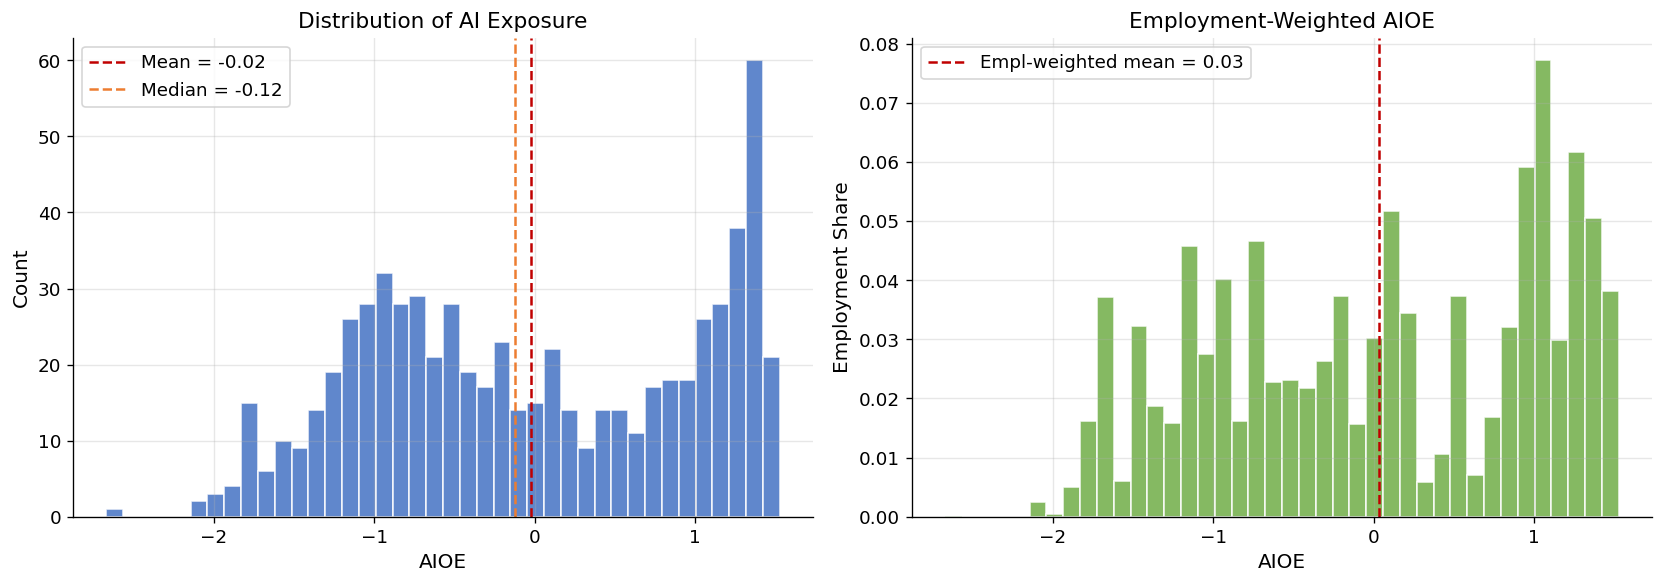

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['aioe'], bins=40, color='#4472C4', edgecolor='white', alpha=0.85)
axes[0].axvline(df['aioe'].mean(), color='#C00000', ls='--', lw=1.5, label=f'Mean = {df["aioe"].mean():.2f}')
axes[0].axvline(df['aioe'].median(), color='#ED7D31', ls='--', lw=1.5, label=f'Median = {df["aioe"].median():.2f}')
axes[0].set_xlabel('AIOE'); axes[0].set_ylabel('Count'); axes[0].set_title('Distribution of AI Exposure'); axes[0].legend()

w = df['employment'] / df['employment'].sum()
axes[1].hist(df['aioe'], bins=40, weights=w, color='#70AD47', edgecolor='white', alpha=0.85)
wm = np.average(df['aioe'], weights=df['employment'])
axes[1].axvline(wm, color='#C00000', ls='--', lw=1.5, label=f'Empl-weighted mean = {wm:.2f}')
axes[1].set_xlabel('AIOE'); axes[1].set_ylabel('Employment Share'); axes[1].set_title('Employment-Weighted AIOE'); axes[1].legend()
plt.tight_layout()
plt.savefig('figures/fig1_aioe_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

### 2.2 Top and Bottom Occupations by AI Exposure


=== TOP 20 HIGHEST AI EXPOSURE ===
  Genetic Counselors                                         AIOE:  1.528  Wage:$  102,890
  Financial Examiners                                        AIOE:  1.526  Wage:$  103,650
  Actuaries                                                  AIOE:  1.516  Wage:$  134,990
  Budget Analysts                                            AIOE:  1.503  Wage:$   93,920
  Judges, Magistrate Judges, and Magistrates                 AIOE:  1.496  Wage:$  143,110
  Procurement Clerks                                         AIOE:  1.488  Wage:$   50,430
  Accountants and Auditors                                   AIOE:  1.482  Wage:$   93,520
  Mathematicians                                             AIOE:  1.472  Wage:$  122,520
  Judicial Law Clerks                                        AIOE:  1.463  Wage:$   69,850
  Education Administrators, Postsecondary                    AIOE:  1.461  Wage:$  124,450
  Financial Managers                                  

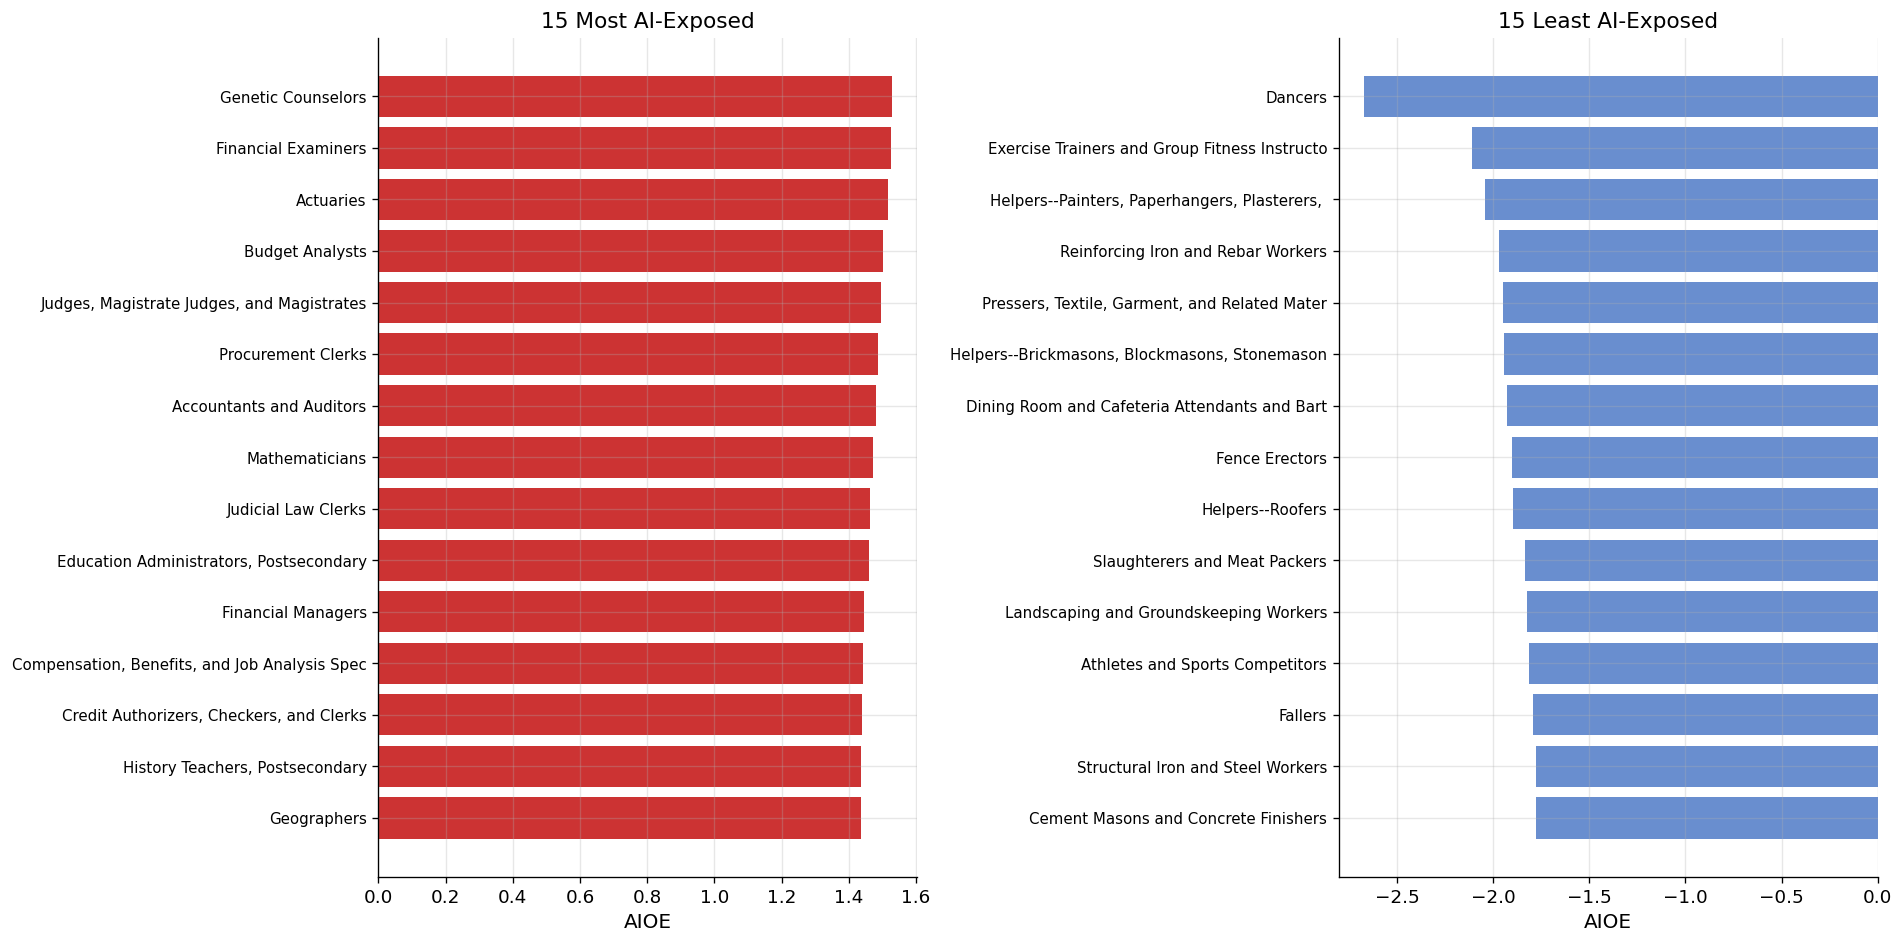

In [7]:
for label, subset in [("TOP 20 HIGHEST", df.nlargest(20,'aioe')), ("TOP 20 LOWEST", df.nsmallest(20,'aioe'))]:
    print(f"\n=== {label} AI EXPOSURE ===")
    for _, r in subset.iterrows():
        wage = f"${r['annual_mean_wage']:>9,.0f}" if pd.notna(r['annual_mean_wage']) else "      N/A"
        print(f"  {r['occupation_title']:<58} AIOE:{r['aioe']:>7.3f}  Wage:{wage}")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, sub, title, color in [(axes[0], df.nlargest(15,'aioe'), '15 Most AI-Exposed', '#C00000'),
                               (axes[1], df.nsmallest(15,'aioe'), '15 Least AI-Exposed', '#4472C4')]:
    ax.barh(range(len(sub)), sub['aioe'].values, color=color, alpha=0.8)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels([t[:45] for t in sub['occupation_title']], fontsize=9)
    ax.set_xlabel('AIOE'); ax.set_title(title); ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig2_top_bottom_occupations.png', dpi=200, bbox_inches='tight')
plt.show()

### 2.3 AI Exposure by Major Occupation Group

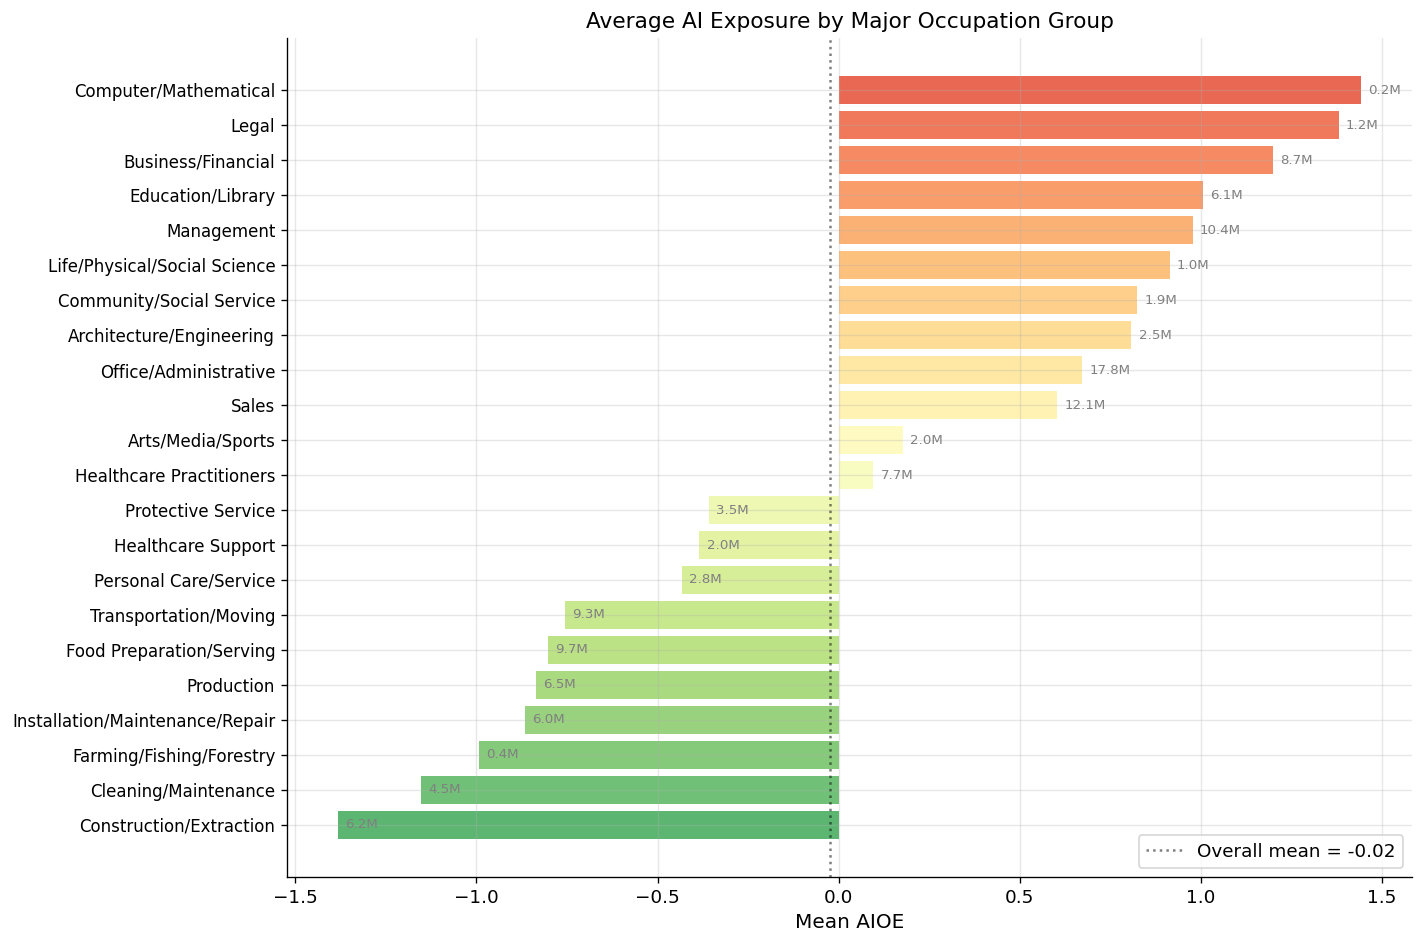

In [8]:
gs = df.groupby('occupation_group').agg(mean_aioe=('aioe','mean'), total_emp=('employment','sum'),
    mean_wage=('annual_mean_wage','mean'), n=('aioe','count')).sort_values('mean_aioe').reset_index()
for i, r in gs.iterrows():
    g = df[df['occupation_group']==r['occupation_group']]
    gs.loc[i,'weighted_aioe'] = np.average(g['aioe'], weights=g['employment'])

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(gs)))
ax.barh(range(len(gs)), gs['mean_aioe'].values, color=colors, alpha=0.85)
ax.set_yticks(range(len(gs)))
ax.set_yticklabels(gs['occupation_group'], fontsize=10)
ax.set_xlabel('Mean AIOE'); ax.set_title('Average AI Exposure by Major Occupation Group')
ax.axvline(df['aioe'].mean(), color='black', ls=':', alpha=0.5, label=f'Overall mean = {df["aioe"].mean():.2f}')
for i, (_, r) in enumerate(gs.iterrows()):
    ax.text(r['mean_aioe']+0.02, i, f'{r["total_emp"]/1e6:.1f}M', va='center', fontsize=8, color='gray')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/fig3_aioe_by_group.png', dpi=200, bbox_inches='tight')
plt.show()

### 2.4 AI Exposure vs. Wages

A central question is whether AI exposure is concentrated among high-wage or low-wage workers. Unlike earlier automation that affected routine manual tasks, AI is expected to disproportionately affect cognitive, analytical occupations.

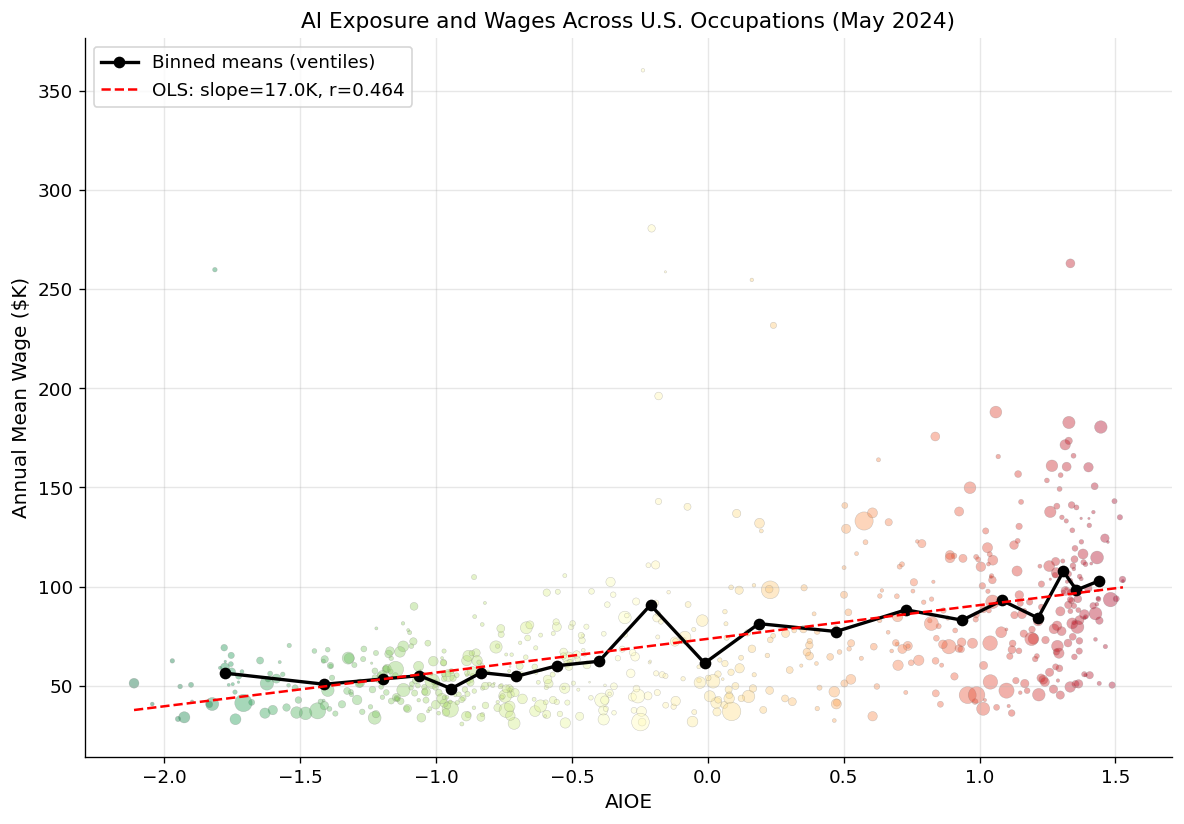

r(AIOE, wage) = 0.4640 | r(AIOE, log wage) = 0.5413


In [9]:
vdf = df.dropna(subset=['annual_mean_wage']).copy()
fig, ax = plt.subplots(figsize=(10, 7))
sizes = np.sqrt(vdf['employment']/1000)*2
ax.scatter(vdf['aioe'], vdf['annual_mean_wage']/1000, s=sizes, alpha=0.4, c=vdf['aioe'], cmap='RdYlGn_r', edgecolors='gray', linewidth=0.3)

n_bins = 20
vdf['aioe_bin'] = pd.qcut(vdf['aioe'], n_bins, labels=False, duplicates='drop')
binned = vdf.groupby('aioe_bin').agg(am=('aioe','mean'), wm=('annual_mean_wage','mean'))
ax.plot(binned['am'], binned['wm']/1000, 'ko-', ms=6, lw=2, label='Binned means (ventiles)')

slope, intercept, r_val, p_val, se = stats.linregress(vdf['aioe'], vdf['annual_mean_wage']/1000)
xl = np.linspace(vdf['aioe'].min(), vdf['aioe'].max(), 100)
ax.plot(xl, intercept+slope*xl, 'r--', lw=1.5, label=f'OLS: slope={slope:.1f}K, r={r_val:.3f}')
ax.set_xlabel('AIOE'); ax.set_ylabel('Annual Mean Wage ($K)')
ax.set_title('AI Exposure and Wages Across U.S. Occupations (May 2024)'); ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('figures/fig4_aioe_vs_wages.png', dpi=200, bbox_inches='tight')
plt.show()

r_logw, p_logw = stats.pearsonr(vdf['aioe'], np.log(vdf['annual_mean_wage']))
print(f"r(AIOE, wage) = {r_val:.4f} | r(AIOE, log wage) = {r_logw:.4f}")

### 2.5 AI Exposure by Education Level

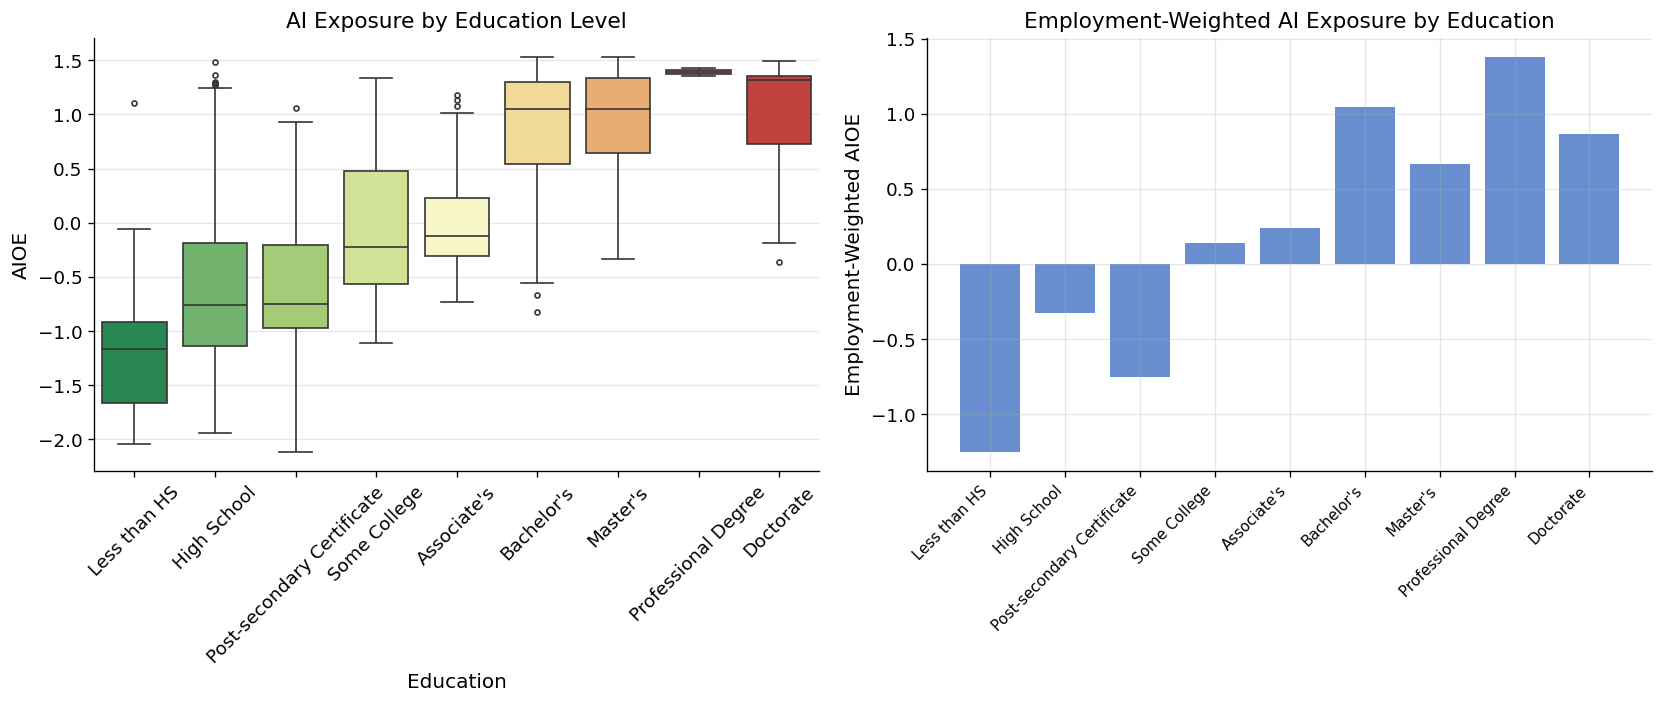

In [10]:
edf = vdf[vdf['education_label'].notna()].copy()
edu_order = [l for l in ['Less than HS','High School','Post-secondary Certificate','Some College',
    "Associate's","Bachelor's","Master's",'Professional Degree','Doctorate'] if l in edf['education_label'].values]
edf['education_label'] = pd.Categorical(edf['education_label'], categories=edu_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=edf, x='education_label', y='aioe', ax=axes[0], palette='RdYlGn_r', order=edu_order, fliersize=3)
axes[0].set_xlabel('Education'); axes[0].set_ylabel('AIOE'); axes[0].set_title('AI Exposure by Education Level')
axes[0].tick_params(axis='x', rotation=45)

ee = edf.groupby('education_label', observed=True).apply(lambda x: pd.Series({
    'wa': np.average(x['aioe'], weights=x['employment']), 'te': x['employment'].sum()})).reset_index()
axes[1].bar(range(len(ee)), ee['wa'], color='#4472C4', alpha=0.8)
axes[1].set_xticks(range(len(ee)))
axes[1].set_xticklabels(ee['education_label'], rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Employment-Weighted AIOE'); axes[1].set_title('Employment-Weighted AI Exposure by Education')
plt.tight_layout()
plt.savefig('figures/fig5_aioe_by_education.png', dpi=200, bbox_inches='tight')
plt.show()

### 2.6 Geographic Distribution (State AIGE)

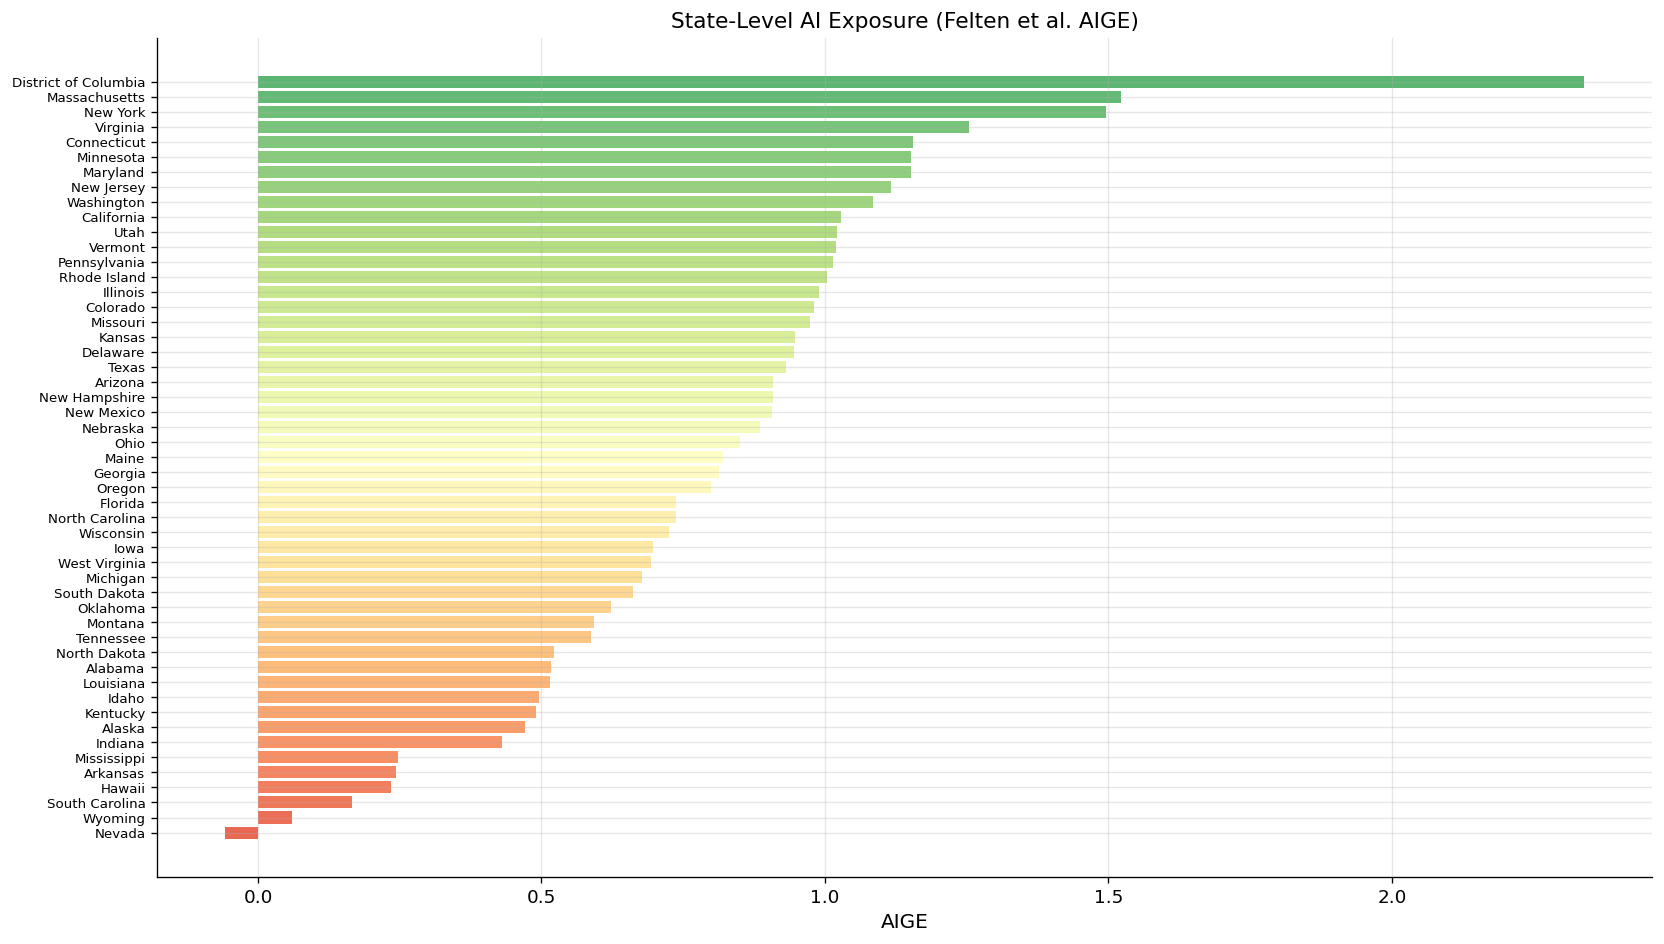

Top 5 states: ['District of Columbia', 'Massachusetts', 'New York', 'Virginia', 'Connecticut']


In [11]:
sa = aige[aige['fips_code']%1000==0].copy()
sa = sa[(sa['fips_code']<60000)&(sa['fips_code']>0)].sort_values('aige', ascending=False)
fig, ax = plt.subplots(figsize=(14, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(sa)))
ax.barh(range(len(sa)), sa['aige'].values, color=colors, alpha=0.85)
ax.set_yticks(range(len(sa)))
ax.set_yticklabels(sa['geographic_area'], fontsize=8)
ax.set_xlabel('AIGE'); ax.set_title('State-Level AI Exposure (Felten et al. AIGE)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig6_state_aige.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Top 5 states: {sa.head(5)['geographic_area'].tolist()}")

### 2.7 Industry-Level AI Exposure

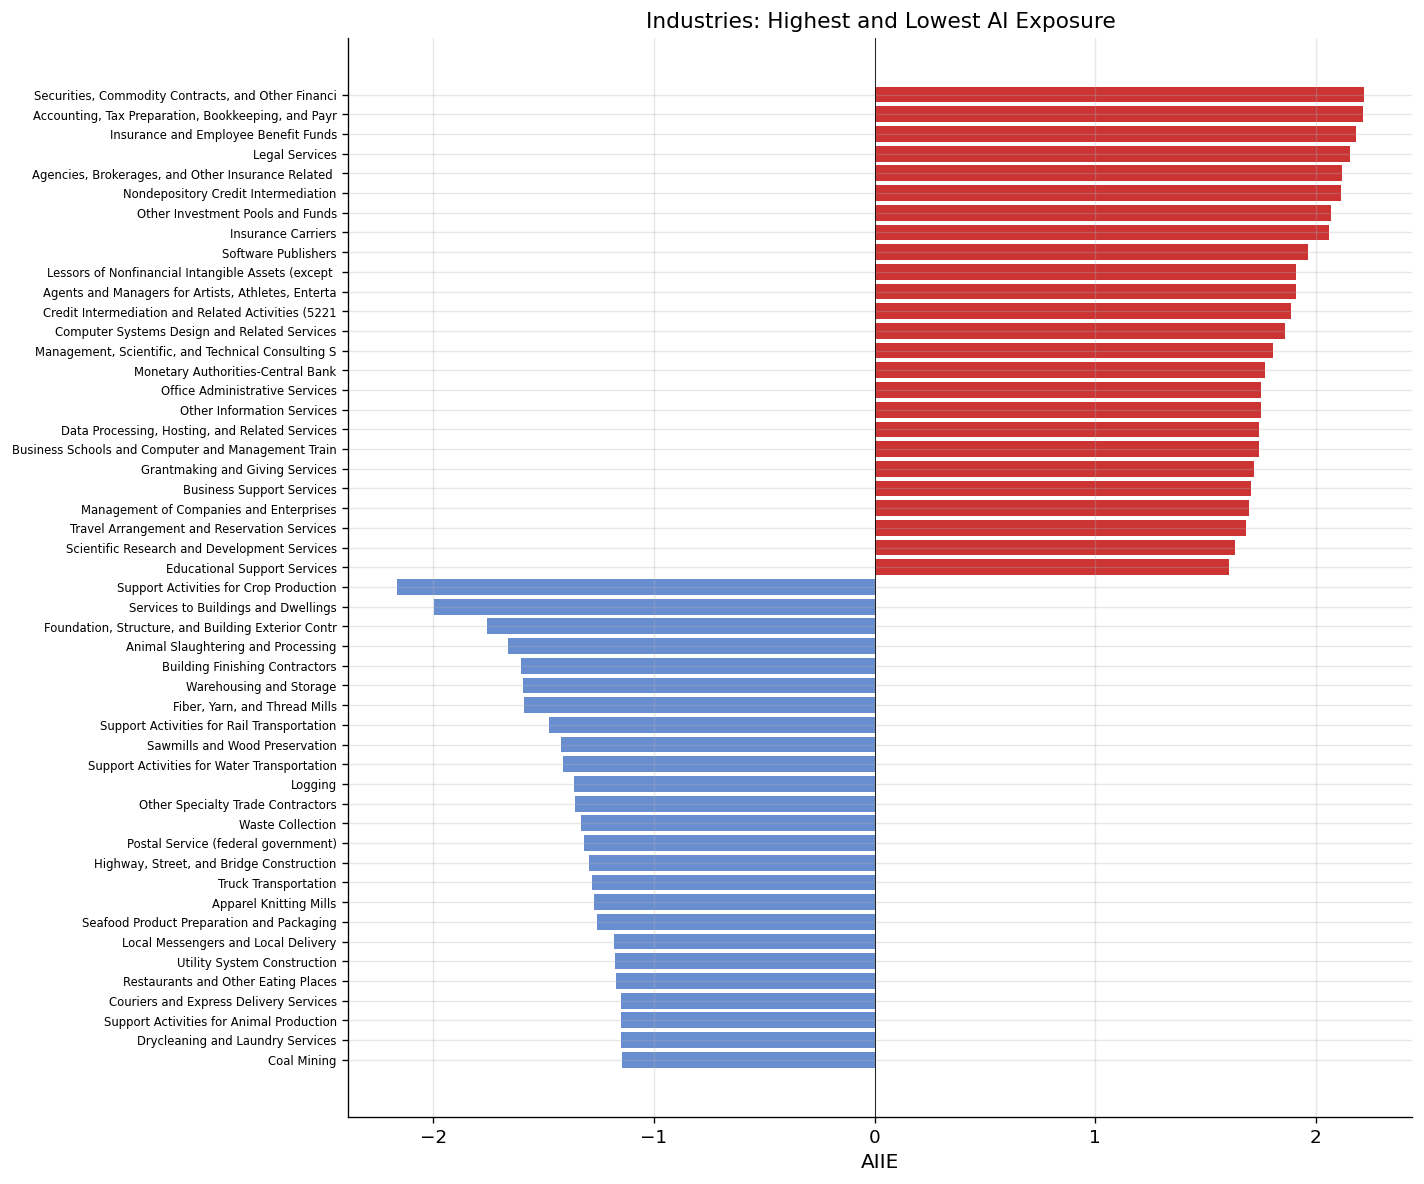

In [12]:
top_i = aiie.nlargest(25,'aiie'); bot_i = aiie.nsmallest(25,'aiie')
di = pd.concat([top_i, bot_i])
fig, ax = plt.subplots(figsize=(12, 10))
c = ['#C00000' if x>0 else '#4472C4' for x in di['aiie']]
ax.barh(range(len(di)), di['aiie'].values, color=c, alpha=0.8)
ax.set_yticks(range(len(di)))
ax.set_yticklabels([t[:50] for t in di['industry_title']], fontsize=7)
ax.set_xlabel('AIIE'); ax.set_title('Industries: Highest and Lowest AI Exposure')
ax.axvline(0, color='black', lw=0.5); ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig7_industry_aiie.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Statistical Analysis

### 3.1 Correlation Matrix

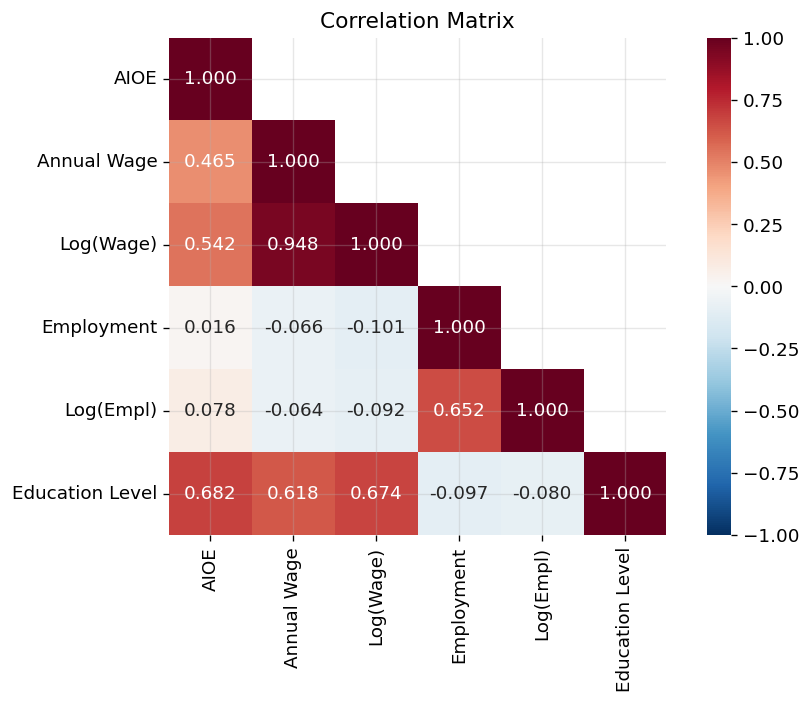


Key correlations with AIOE:
  AIOE vs Annual Wage: r = 0.4655, p = 9.66e-37
  AIOE vs Log(Wage): r = 0.5420, p = 1.35e-51
  AIOE vs Employment: r = 0.0165, p = 6.73e-01
  AIOE vs Log(Empl): r = 0.0779, p = 4.56e-02
  AIOE vs Education Level: r = 0.6820, p = 2.40e-91


In [13]:
cv = ['aioe','annual_mean_wage','log_annual_wage','employment','log_employment','typical_education']
cl = ['AIOE','Annual Wage','Log(Wage)','Employment','Log(Empl)','Education Level']
cdf = vdf[cv].dropna()
cm = cdf.corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(cm, dtype=bool), k=1)
sns.heatmap(cm, annot=True, fmt='.3f', cmap='RdBu_r', center=0, xticklabels=cl, yticklabels=cl,
    mask=mask, ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.savefig('figures/fig8_correlation_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nKey correlations with AIOE:")
for v, l in zip(cv[1:], cl[1:]):
    r, p = stats.pearsonr(cdf['aioe'], cdf[v])
    print(f"  AIOE vs {l}: r = {r:.4f}, p = {p:.2e}")

### 3.2 OLS Regression Analysis

Following the progressive model specification from my ECO483 paper:
- **Model 1 (Bivariate):** Log(annual wage) ~ AIOE
- **Model 2 (Multivariate):** + education + occupation group FE + log employment
- **Model 3 (Interaction):** + AIOE × education interactions

In [14]:
rdf = vdf[['log_annual_wage','aioe','aioe_z','log_employment','typical_education',
    'occupation_group','employment','annual_mean_wage']].dropna().copy()
rdf['edu_hs_or_less'] = (rdf['typical_education']<=2).astype(float)
rdf['edu_some_college'] = rdf['typical_education'].isin([3,4,5]).astype(float)
rdf['edu_graduate'] = (rdf['typical_education']>=7).astype(float)
occ_dum = pd.get_dummies(rdf['occupation_group'], prefix='occ', drop_first=True).astype(float)
print(f"Regression sample: {len(rdf)} occupations\n")

# Model 1: Bivariate
m1 = sm.OLS(rdf['log_annual_wage'], sm.add_constant(rdf[['aioe']].astype(float))).fit()
print(f"MODEL 1 (Bivariate)")
print(f"  AIOE = {m1.params['aioe']:.4f} (p = {m1.pvalues['aioe']:.2e})")
print(f"  R² = {m1.rsquared:.4f}\n")

# Model 2: Multivariate
X2 = pd.concat([rdf[['aioe','log_employment','edu_hs_or_less','edu_some_college','edu_graduate']], occ_dum], axis=1)
m2 = sm.OLS(rdf['log_annual_wage'], sm.add_constant(X2)).fit()
print(f"MODEL 2 (Multivariate)")
print(f"  AIOE = {m2.params['aioe']:.4f} (p = {m2.pvalues['aioe']:.2e})")
print(f"  R² = {m2.rsquared:.4f}\n")

# Model 3: Interaction
rdf['aioe_x_grad'] = rdf['aioe'] * rdf['edu_graduate']
rdf['aioe_x_hsless'] = rdf['aioe'] * rdf['edu_hs_or_less']
X3 = pd.concat([rdf[['aioe','log_employment','edu_hs_or_less','edu_some_college',
    'edu_graduate','aioe_x_grad','aioe_x_hsless']], occ_dum], axis=1)
m3 = sm.OLS(rdf['log_annual_wage'], sm.add_constant(X3)).fit()
print(f"MODEL 3 (Interaction)")
print(f"  AIOE = {m3.params['aioe']:.4f}")
print(f"  AIOE × Graduate = {m3.params['aioe_x_grad']:.4f} (p = {m3.pvalues['aioe_x_grad']:.4f})")
print(f"  R² = {m3.rsquared:.4f}")

Regression sample: 659 occupations

MODEL 1 (Bivariate)
  AIOE = 0.2256 (p = 1.35e-51)
  R² = 0.2938

MODEL 2 (Multivariate)
  AIOE = 0.1048 (p = 9.28e-07)
  R² = 0.6402

MODEL 3 (Interaction)
  AIOE = 0.1345
  AIOE × Graduate = -0.1505 (p = 0.0276)
  R² = 0.6430


### 3.3 Regression Summary Table

In [15]:
print(f"{'='*80}")
print(f"TABLE 1: OLS REGRESSION RESULTS - Log(Annual Wage) on AI Exposure")
print(f"{'='*80}")
print(f"{'Variable':<30} {'Model 1':>12} {'Model 2':>12} {'Model 3':>12}")
print(f"{'-'*80}")
def fc(m, v):
    if v in m.params:
        c, p = m.params[v], m.pvalues[v]
        s = '***' if p<.001 else '**' if p<.01 else '*' if p<.05 else ''
        return f"{c:.4f}{s}"
    return ""
for v, l in [('const','Intercept'),('aioe','AIOE'),('log_employment','Log(Employment)'),
    ('edu_hs_or_less','HS or Less'),('edu_some_college','Some College'),('edu_graduate','Graduate+'),
    ('aioe_x_grad','AIOE x Graduate'),('aioe_x_hsless','AIOE x HS or Less')]:
    c1 = fc(m1,v) if v in ['const','aioe'] else ''
    print(f"{l:<30} {c1:>12} {fc(m2,v):>12} {fc(m3,v):>12}")
print(f"{'-'*80}")
print(f"{'Occupation Group FE':<30} {'No':>12} {'Yes':>12} {'Yes':>12}")
print(f"{'R-squared':<30} {m1.rsquared:>12.4f} {m2.rsquared:>12.4f} {m3.rsquared:>12.4f}")
print(f"{'Adj. R-squared':<30} {m1.rsquared_adj:>12.4f} {m2.rsquared_adj:>12.4f} {m3.rsquared_adj:>12.4f}")
print(f"{'N':<30} {int(m1.nobs):>12} {int(m2.nobs):>12} {int(m3.nobs):>12}")
print(f"{'='*80}")
print("* p < 0.05, ** p < 0.01, *** p < 0.001")

TABLE 1: OLS REGRESSION RESULTS — Log(Annual Wage) on AI Exposure
Variable                            Model 1      Model 2      Model 3
--------------------------------------------------------------------------------
Intercept                        11.1133***   11.6248***   11.5939***
AIOE                              0.2256***    0.1048***    0.1345***
Log(Employment)                                 -0.0158*     -0.0162*
HS or Less                                    -0.3225***   -0.2945***
Some College                                  -0.1624***     -0.1228*
Graduate+                                      0.2318***    0.3707***
AIOE x Graduate                                              -0.1505*
AIOE x HS or Less                                             -0.0242
--------------------------------------------------------------------------------
Occupation Group FE                      No          Yes          Yes
R-squared                            0.2938       0.6402       0.6430
Ad

### 3.4 Standardized Coefficient Plot

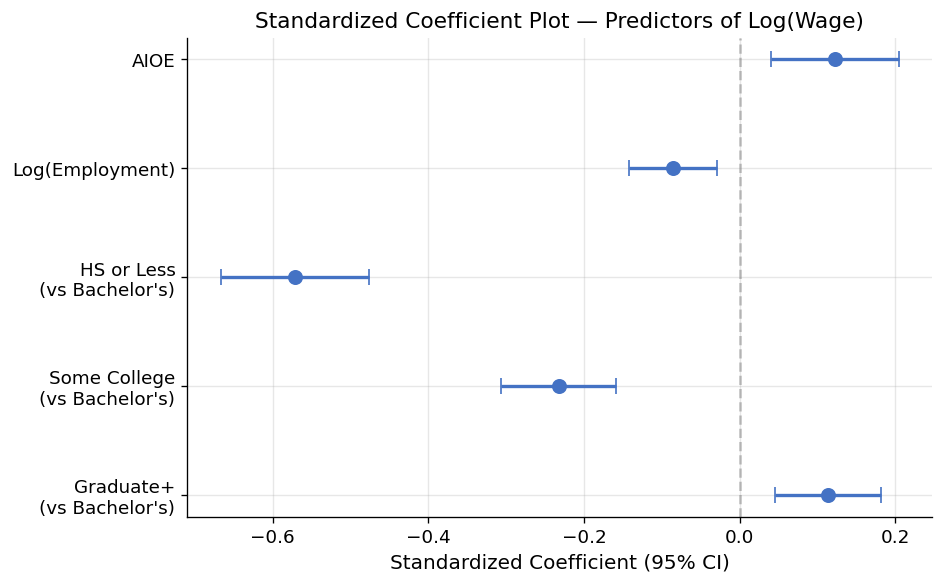

In [16]:
sv = ['aioe','log_employment','edu_hs_or_less','edu_some_college','edu_graduate']
sdf = rdf.copy()
for v in sv: sdf[v] = (sdf[v]-sdf[v].mean())/sdf[v].std()
sdf['log_annual_wage'] = (sdf['log_annual_wage']-sdf['log_annual_wage'].mean())/sdf['log_annual_wage'].std()
ms = sm.OLS(sdf['log_annual_wage'], sm.add_constant(sdf[sv].astype(float))).fit()

fig, ax = plt.subplots(figsize=(8, 5))
coefs = ms.params[1:]; ci = ms.conf_int().iloc[1:]
labels = ['AIOE','Log(Employment)',"HS or Less\n(vs Bachelor's)","Some College\n(vs Bachelor's)","Graduate+\n(vs Bachelor's)"]
ax.errorbar(coefs, range(len(coefs)), xerr=[coefs-ci[0], ci[1]-coefs], fmt='o', color='#4472C4', ms=8, capsize=5, lw=2)
ax.axvline(0, color='gray', ls='--', alpha=0.5)
ax.set_yticks(range(len(coefs))); ax.set_yticklabels(labels)
ax.set_xlabel('Standardized Coefficient (95% CI)'); ax.set_title('Standardized Coefficient Plot - Predictors of Log(Wage)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/fig9_coefficient_plot.png', dpi=200, bbox_inches='tight')
plt.show()

### 3.5 Binned Scatter Plot: AIOE vs. Wages by Education Level

Following the visual strategy from my ECO483 analysis, I split the AIOE–wage relationship by educational requirements.

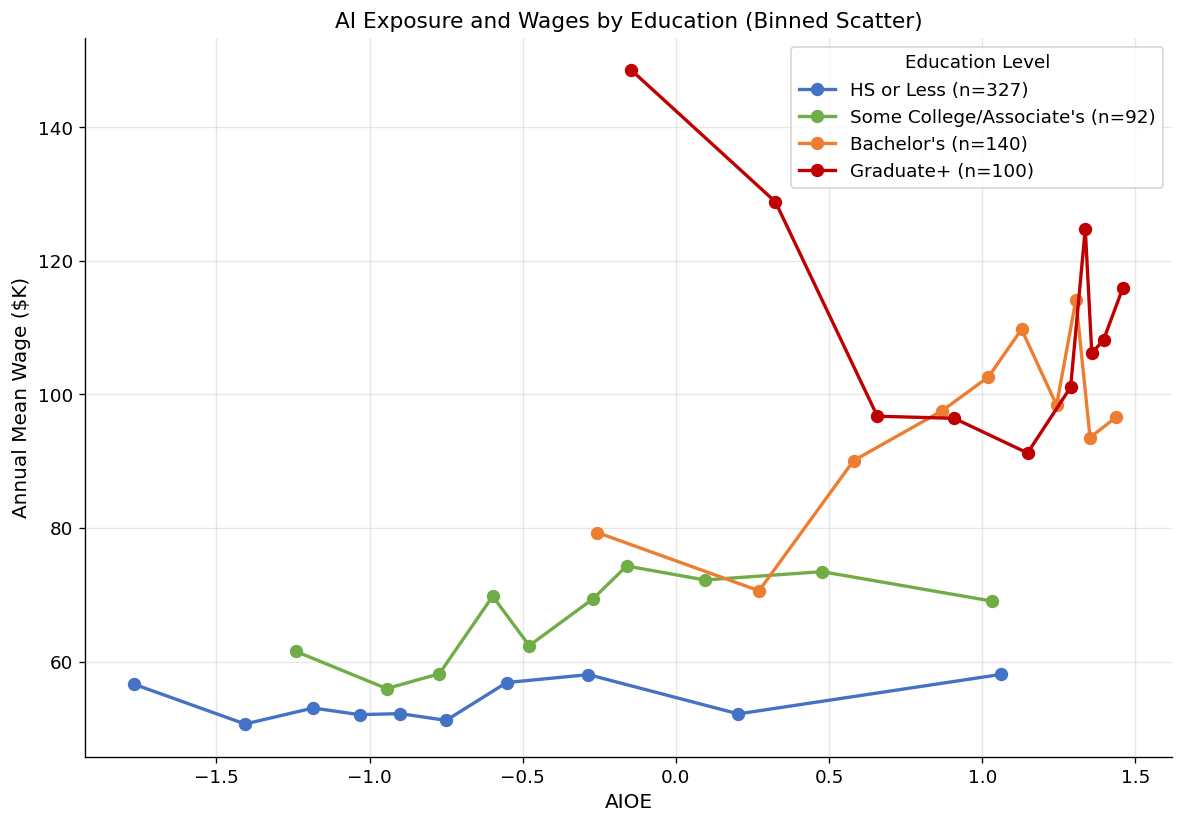

In [17]:
fig, ax = plt.subplots(figsize=(10, 7))
edu_groups = {'HS or Less': rdf['typical_education']<=2,
    "Some College/Associate's": rdf['typical_education'].isin([3,4,5]),
    "Bachelor's": rdf['typical_education']==6, "Graduate+": rdf['typical_education']>=7}
colors_e = ['#4472C4','#70AD47','#ED7D31','#C00000']
for (lab, mask), col in zip(edu_groups.items(), colors_e):
    s = rdf[mask]
    if len(s)<5: continue
    nb = min(10, len(s)//3)
    if nb<3: continue
    s = s.copy(); s['b'] = pd.qcut(s['aioe'], nb, labels=False, duplicates='drop')
    b = s.groupby('b').agg(am=('aioe','mean'), wm=('annual_mean_wage','mean'))
    ax.plot(b['am'], b['wm']/1000, 'o-', color=col, ms=7, lw=2, label=f'{lab} (n={len(s)})')
ax.set_xlabel('AIOE'); ax.set_ylabel('Annual Mean Wage ($K)')
ax.set_title('AI Exposure and Wages by Education (Binned Scatter)'); ax.legend(title='Education Level')
plt.tight_layout()
plt.savefig('figures/fig10_binned_scatter_education.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. K-Means Clustering: AI Displacement Risk Tiers

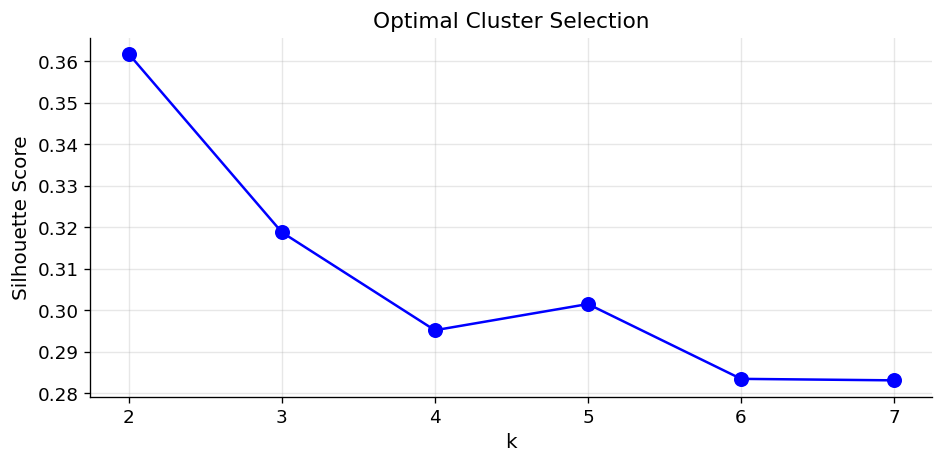

Cluster Summary:
  Low Risk       : n=219, Mean AIOE=-0.818, Mean Wage=$56,139, Total Emp=4.3M
  Moderate Risk  : n=150, Mean AIOE=-0.716, Mean Wage=$48,567, Total Emp=60.2M
  Elevated Risk  : n=144, Mean AIOE=0.888, Mean Wage=$113,245, Total Emp=3.5M
  High Risk      : n=157, Mean AIOE=0.929, Mean Wage=$84,720, Total Emp=54.5M


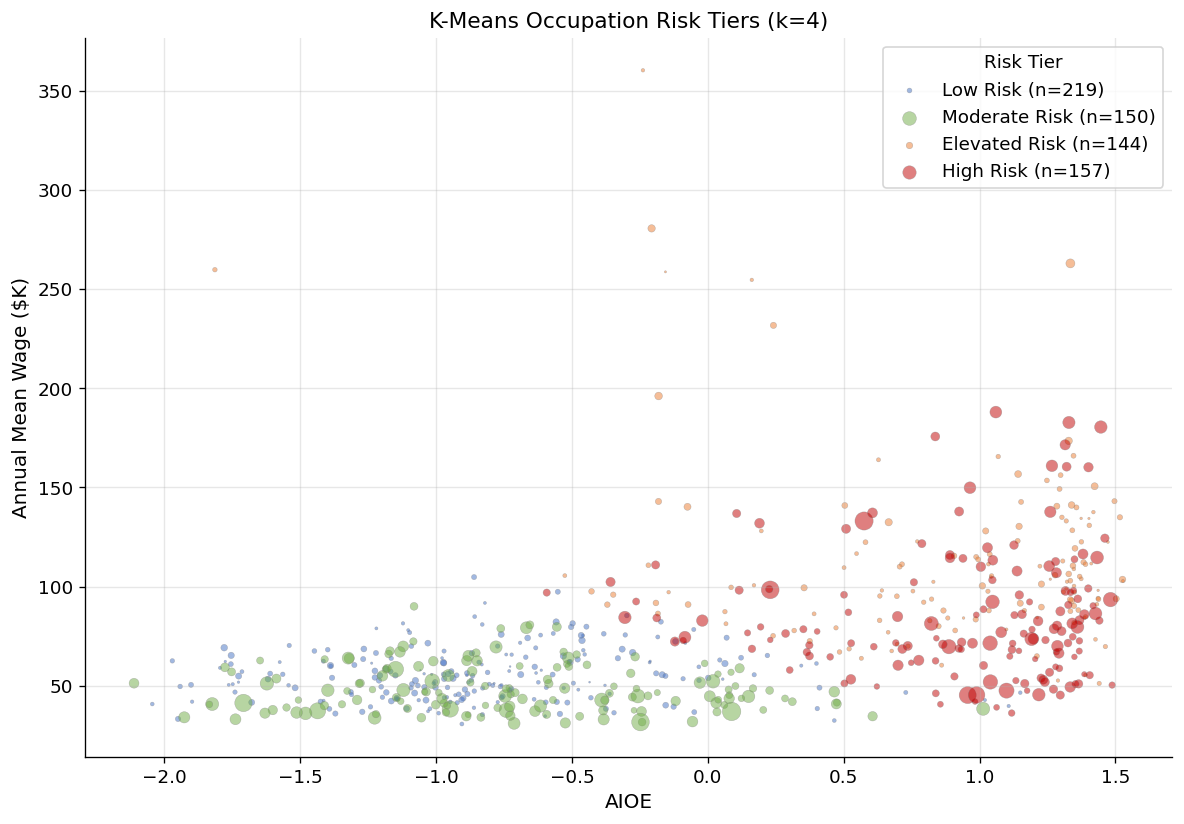

In [18]:
cf = ['aioe','log_annual_wage','log_employment']
clu = vdf[cf + ['occupation_title','employment','annual_mean_wage','occupation_group']].dropna()
scaler = StandardScaler(); Xs = scaler.fit_transform(clu[cf])

sil = {k: silhouette_score(Xs, KMeans(k, random_state=42, n_init=10).fit_predict(Xs)) for k in range(2,8)}
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(sil.keys(), sil.values(), 'bo-', ms=8); ax.set_xlabel('k'); ax.set_ylabel('Silhouette Score')
ax.set_title('Optimal Cluster Selection')
plt.tight_layout()
plt.savefig('figures/fig11_silhouette.png', dpi=200, bbox_inches='tight')
plt.show()

km = KMeans(4, random_state=42, n_init=10)
clu = clu.copy()
clu['cluster'] = km.fit_predict(Xs)
cs = clu.groupby('cluster').agg(ma=('aioe','mean'), mw=('annual_mean_wage','mean'),
    te=('employment','sum'), n=('cluster','count')).sort_values('ma')
tier_map = dict(zip(cs.index, ['Low Risk','Moderate Risk','Elevated Risk','High Risk']))
clu['risk_tier'] = clu['cluster'].map(tier_map)

print("Cluster Summary:")
for cl_idx in cs.index:
    s = cs.loc[cl_idx]
    print(f"  {tier_map[cl_idx]:<15}: n={s['n']:.0f}, Mean AIOE={s['ma']:.3f}, Mean Wage=${s['mw']:,.0f}, Total Emp={s['te']/1e6:.1f}M")

fig, ax = plt.subplots(figsize=(10, 7))
tc = {'Low Risk':'#4472C4','Moderate Risk':'#70AD47','Elevated Risk':'#ED7D31','High Risk':'#C00000'}
for t in ['Low Risk','Moderate Risk','Elevated Risk','High Risk']:
    s = clu[clu['risk_tier']==t]; sz = np.sqrt(s['employment']/1000)*2
    ax.scatter(s['aioe'], s['annual_mean_wage']/1000, s=sz, alpha=0.5, label=f'{t} (n={len(s)})',
              color=tc[t], edgecolors='gray', lw=0.3)
ax.set_xlabel('AIOE'); ax.set_ylabel('Annual Mean Wage ($K)')
ax.set_title('K-Means Occupation Risk Tiers (k=4)'); ax.legend(title='Risk Tier')
plt.tight_layout()
plt.savefig('figures/fig12_cluster_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

In [19]:
print("\n=== REPRESENTATIVE OCCUPATIONS BY RISK TIER ===")
for tier in ['High Risk','Elevated Risk','Moderate Risk','Low Risk']:
    subset = clu[clu['risk_tier']==tier].nlargest(8, 'employment')
    print(f"\n{tier}:")
    for _, r in subset.iterrows():
        print(f"  {r['occupation_title']:<50} AIOE={r['aioe']:.3f}  Wage=${r['annual_mean_wage']:>9,.0f}")


=== REPRESENTATIVE OCCUPATIONS BY RISK TIER ===

High Risk:
  General and Operations Managers                    AIOE=0.575  Wage=$  133,120
  Registered Nurses                                  AIOE=0.229  Wage=$   98,430
  Customer Service Representatives                   AIOE=0.956  Wage=$   45,380
  Office Clerks, General                             AIOE=0.989  Wage=$   45,470
  Secretaries and Administrative Assistants, Except Legal, Medical, and Executive AIOE=1.099  Wage=$   47,640
  First-Line Supervisors of Office and Administrative Support Workers AIOE=1.039  Wage=$   71,560
  Bookkeeping, Accounting, and Auditing Clerks       AIOE=1.040  Wage=$   52,020
  Accountants and Auditors                           AIOE=1.482  Wage=$   93,520

Elevated Risk:
  Chief Executives                                   AIOE=1.334  Wage=$  262,930
  Dentists, General                                  AIOE=-0.181  Wage=$  196,100
  Natural Sciences Managers                          AIOE=1.328  W

## 5. Difference-in-Differences Analysis: Employment and Wage Dynamics, 2019–2024

The cross-sectional analysis in Section 4 establishes that AI exposure is concentrated in high-wage, cognitive occupations. A natural follow-up is whether high-exposure occupations are already experiencing differential employment or wage trends. To investigate this, I exploit the panel structure created by matching BLS OEWS data from May 2019 (`national_M2019_dl.xlsx`) and May 2024 (`national_M2024_dl.xlsx`) at the six-digit SOC level. This five-year window captures the period spanning the development and widespread deployment of large language models and generative AI tools, including ChatGPT (November 2022) and GPT-4 (March 2023).

### 5.1 Panel Construction


In [20]:
# Build the 2019-2024 panel by restricting df to occupations with complete data in both years.
# df already contains employment (2024), employment_2019, annual_mean_wage (2024), and annual_mean_wage_2019,
# merged earlier in Section 1.4.

panel = df.dropna(subset=['employment', 'employment_2019',
                          'annual_mean_wage', 'annual_mean_wage_2019']).copy()

# Rename for clarity within the panel analysis
panel = panel.rename(columns={'employment': 'tot_emp_2024',
                              'employment_2019': 'tot_emp_2019',
                              'annual_mean_wage': 'a_mean_2024',
                              'annual_mean_wage_2019': 'a_mean_2019'})

# Logs and changes
panel['log_emp_2019']   = np.log(panel['tot_emp_2019'])
panel['log_emp_2024']   = np.log(panel['tot_emp_2024'])
panel['log_emp_change'] = panel['log_emp_2024'] - panel['log_emp_2019']
panel['log_wage_2019']  = np.log(panel['a_mean_2019'])
panel['log_wage_2024']  = np.log(panel['a_mean_2024'])
panel['log_wage_change'] = panel['log_wage_2024'] - panel['log_wage_2019']
panel['emp_change_pct_p']  = (panel['tot_emp_2024'] - panel['tot_emp_2019']) / panel['tot_emp_2019'] * 100
panel['wage_change_pct_p'] = (panel['a_mean_2024']   - panel['a_mean_2019'])   / panel['a_mean_2019']   * 100

# Exposure groups: median split and terciles
median_aioe = panel['aioe'].median()
panel['high_exposure'] = (panel['aioe'] >= median_aioe).astype(int)
panel['aioe_tercile']  = pd.qcut(panel['aioe'], 3, labels=['Low', 'Medium', 'High'])

print(f"Panel: {len(panel)} occupations matched across 2019 and 2024")
print(f"Median AIOE split: {median_aioe:.3f}")
print(f"High exposure: {panel['high_exposure'].sum()}, Low exposure: {(1 - panel['high_exposure']).sum()}")

Panel: 661 occupations matched across 2019 and 2024
Median AIOE split: -0.156
High exposure: 331, Low exposure: 330


### 5.2 Summary Statistics by Exposure Group


In [21]:
print(f"{'='*80}")
print(f"PANEL SUMMARY: 2019–2024 EMPLOYMENT AND WAGE CHANGES BY AI EXPOSURE")
print(f"{'='*80}")

for grp_val, grp in panel.groupby('high_exposure'):
    label = 'HIGH Exposure' if grp_val == 1 else 'LOW Exposure'
    agg_emp_chg = (grp['tot_emp_2024'].sum() - grp['tot_emp_2019'].sum()) / grp['tot_emp_2019'].sum() * 100
    print(f"\n{label} (n = {len(grp)}, median split at AIOE = {median_aioe:.3f}):")
    print(f"  Total employment 2019: {grp['tot_emp_2019'].sum():>12,.0f}")
    print(f"  Total employment 2024: {grp['tot_emp_2024'].sum():>12,.0f}")
    print(f"  Aggregate emp change:  {agg_emp_chg:>+10.2f}%")
    print(f"  Mean occ-level change: {grp['emp_change_pct_p'].mean():>+10.2f}%")
    print(f"  Mean log emp change:   {grp['log_emp_change'].mean():>+10.4f}")
    print(f"  Mean wage growth:      {grp['wage_change_pct_p'].mean():>+10.2f}%")

# Tercile summary
print(f"\n{'='*80}")
print("TERCILE SUMMARY")
print(f"{'='*80}")
for t in ['Low', 'Medium', 'High']:
    sub = panel[panel['aioe_tercile'] == t]
    print(f"  {t:8s} tercile (n={len(sub):3d}): "
          f"mean log emp change = {sub['log_emp_change'].mean():+.4f}, "
          f"mean log wage change = {sub['log_wage_change'].mean():+.4f}")

PANEL SUMMARY: 2019–2024 EMPLOYMENT AND WAGE CHANGES BY AI EXPOSURE

LOW Exposure (n = 330, median split at AIOE = -0.156):
  Total employment 2019:   53,523,520
  Total employment 2024:   53,915,920
  Aggregate emp change:       +0.73%
  Mean occ-level change:      -4.25%
  Mean log emp change:      -0.0793
  Mean wage growth:          +24.53%

HIGH Exposure (n = 331, median split at AIOE = -0.156):
  Total employment 2019:   62,777,000
  Total employment 2024:   65,913,780
  Aggregate emp change:       +5.00%
  Mean occ-level change:      +2.62%
  Mean log emp change:      +0.0047
  Mean wage growth:          +18.20%

TERCILE SUMMARY
  Low      tercile (n=221): mean log emp change = -0.1121, mean log wage change = +0.2210
  Medium   tercile (n=220): mean log emp change = -0.0129, mean log wage change = +0.1953
  High     tercile (n=220): mean log emp change = +0.0136, mean log wage change = +0.1528


### 5.3 First-Difference Regressions

The first-difference approach regresses the *change* in log employment (or log wages) between 2019 and 2024 on AIOE. Under the assumption that unobserved time-invariant occupation characteristics are differenced out, this provides a quasi-causal estimate of whether higher AI exposure is associated with differential labor market trajectories. The specification is:

$$\Delta \log(Y_i) = \alpha + \beta \cdot AIOE_i + \varepsilon_i$$


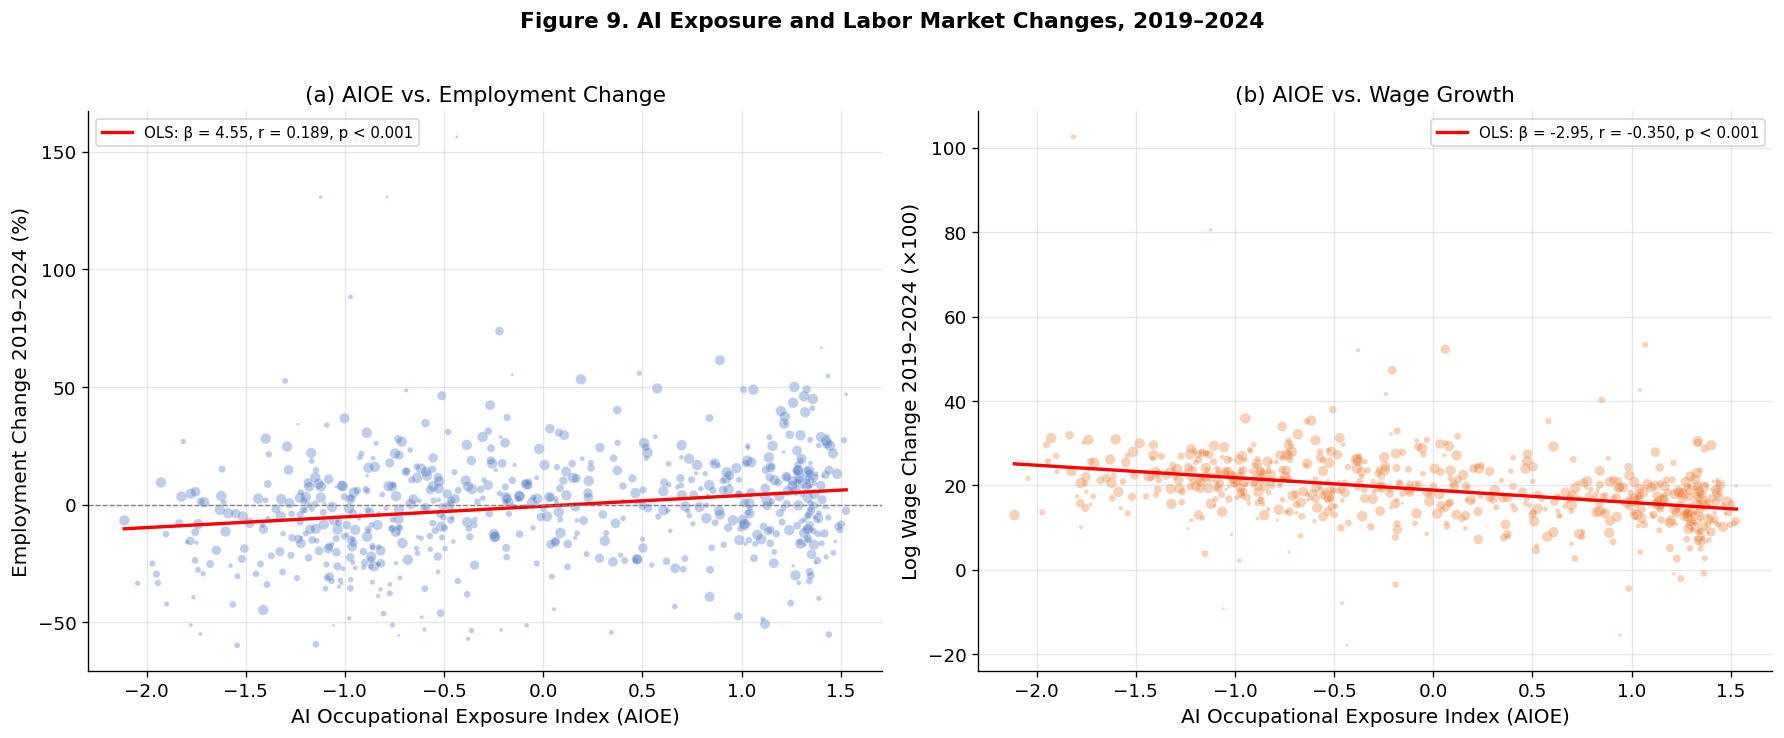

Figure 9. AI exposure vs. employment change (left) and wage growth (right), 2019–2024.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sizes = np.clip(np.sqrt(panel['tot_emp_2019']) / 10, 3, 40)

# (a) Employment change
ax = axes[0]
ax.scatter(panel['aioe'], panel['emp_change_pct_p'], s=sizes, alpha=0.35,
           c='#4472C4', edgecolors='white', linewidth=0.3)
slope, intercept, r_val, p_val, se = stats.linregress(panel['aioe'], panel['emp_change_pct_p'])
x_line = np.linspace(panel['aioe'].min(), panel['aioe'].max(), 100)
ax.plot(x_line, slope * x_line + intercept, 'r-', linewidth=2,
        label=f'OLS: β = {slope:.2f}, r = {r_val:.3f}, p < 0.001')
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('AI Occupational Exposure Index (AIOE)')
ax.set_ylabel('Employment Change 2019–2024 (%)')
ax.set_title('(a) AIOE vs. Employment Change')
ax.legend(fontsize=9, loc='upper left')

# (b) Wage change
ax = axes[1]
ax.scatter(panel['aioe'], panel['log_wage_change'] * 100, s=sizes, alpha=0.35,
           c='#ED7D31', edgecolors='white', linewidth=0.3)
slope2, intercept2, r2, p2, se2 = stats.linregress(panel['aioe'], panel['log_wage_change'] * 100)
ax.plot(x_line, slope2 * x_line + intercept2, 'r-', linewidth=2,
        label=f'OLS: β = {slope2:.2f}, r = {r2:.3f}, p < 0.001')
ax.set_xlabel('AI Occupational Exposure Index (AIOE)')
ax.set_ylabel('Log Wage Change 2019–2024 (×100)')
ax.set_title('(b) AIOE vs. Wage Growth')
ax.legend(fontsize=9, loc='upper right')

plt.suptitle('Figure 9. AI Exposure and Labor Market Changes, 2019–2024',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig9_aioe_emp_wage_change.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9. AI exposure vs. employment change (left) and wage growth (right), 2019–2024.')

In [23]:
print(f"{'='*82}")
print("TABLE 2: FIRST-DIFFERENCE REGRESSIONS - 2019–2024 Changes on AIOE")
print(f"{'='*82}")

# Model 4: Bivariate - employment
X4 = sm.add_constant(panel['aioe'])
m4 = sm.OLS(panel['log_emp_change'], X4).fit(cov_type='HC1')

# Model 5: With controls - employment
X5 = sm.add_constant(panel[['aioe', 'log_emp_2019', 'log_wage_2019']])
m5 = sm.OLS(panel['log_emp_change'], X5).fit(cov_type='HC1')

# Model 6: Bivariate - wages
m6 = sm.OLS(panel['log_wage_change'], X4).fit(cov_type='HC1')

# Model 7: With controls - wages
m7 = sm.OLS(panel['log_wage_change'], X5).fit(cov_type='HC1')

header = f"{'':30s} {'Model 4':>12s} {'Model 5':>12s} {'Model 6':>12s} {'Model 7':>12s}"
print(header)
print(f"{'Dep. Variable':30s} {'Δlog(Emp)':>12s} {'Δlog(Emp)':>12s} {'Δlog(Wage)':>12s} {'Δlog(Wage)':>12s}")
print('-' * 82)

models = [m4, m5, m6, m7]

# AIOE coefficient row
row = f"{'AIOE':30s}"
for m in models:
    idx = list(m.params.index).index('aioe')
    p = m.pvalues.iloc[idx]
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    row += f" {m.params.iloc[idx]:>9.5f}{stars:3s}"
print(row)

# SE row
row = f"{'':30s}"
for m in models:
    idx = list(m.params.index).index('aioe')
    row += f" {'(' + f'{m.bse.iloc[idx]:.5f}' + ')':>12s}"
print(row)

# Baseline controls row
row = f"{'Baseline emp & wage controls':30s}"
for m in models:
    has = len(m.params) > 2
    row += f" {'Yes':>12s}" if has else f" {'No':>12s}"
print(row)

row = f"{'R-squared':30s}"
for m in models:
    row += f" {m.rsquared:>12.4f}"
print(row)

row = f"{'N':30s}"
for m in models:
    row += f" {int(m.nobs):>12d}"
print(row)

print('-' * 82)
print('Robust (HC1) standard errors in parentheses. * p<0.05, ** p<0.01, *** p<0.001')

TABLE 2: FIRST-DIFFERENCE REGRESSIONS — 2019–2024 Changes on AIOE
                                    Model 4      Model 5      Model 6      Model 7
Dep. Variable                     Δlog(Emp)    Δlog(Emp)   Δlog(Wage)   Δlog(Wage)
----------------------------------------------------------------------------------
AIOE                             0.05180***   0.00385     -0.02946***  -0.01641** 
                                  (0.00909)    (0.01070)    (0.00334)    (0.00568)
Baseline emp & wage controls             No          Yes           No          Yes
R-squared                            0.0459       0.1444       0.1226       0.1961
N                                       661          661          661          661
----------------------------------------------------------------------------------
Robust (HC1) standard errors in parentheses. * p<0.05, ** p<0.01, *** p<0.001


### 5.4 Panel Difference-in-Differences

The panel DiD specification stacks 2019 and 2024 observations in long format and estimates:

$$Y_{it} = \alpha + \beta_1 \cdot AIOE_i + \beta_2 \cdot Post_t + \beta_3 \cdot (AIOE_i \times Post_t) + \varepsilon_{it}$$

where $\beta_3$ is the DiD parameter of interest; the differential change in the outcome for occupations with higher AI exposure. Standard errors are clustered at the occupation level.


In [24]:
# Construct long-format panel
long_df = pd.DataFrame({
    'soc_code':      list(panel['soc_code']) * 2,
    'aioe':          list(panel['aioe']) * 2,
    'high_exposure': list(panel['high_exposure']) * 2,
    'log_emp':       list(panel['log_emp_2019'])  + list(panel['log_emp_2024']),
    'log_wage':      list(panel['log_wage_2019']) + list(panel['log_wage_2024']),
    'post':          [0] * len(panel) + [1] * len(panel)
})
long_df['aioe_x_post'] = long_df['aioe'] * long_df['post']

print(f"{'='*62}")
print("TABLE 3: PANEL DiD REGRESSIONS (Clustered SEs by Occupation)")
print(f"{'='*62}")

# DiD on employment
X_did = sm.add_constant(long_df[['aioe', 'post', 'aioe_x_post']])
m_did_emp = sm.OLS(long_df['log_emp'], X_did).fit(
    cov_type='cluster', cov_kwds={'groups': long_df['soc_code']})

# DiD on wages
m_did_wage = sm.OLS(long_df['log_wage'], X_did).fit(
    cov_type='cluster', cov_kwds={'groups': long_df['soc_code']})

header = f"{'':30s} {'Log(Emp)':>15s} {'Log(Wage)':>15s}"
print(header)
print('-' * 62)

for name in ['const', 'aioe', 'post', 'aioe_x_post']:
    label = {'const': 'Constant', 'aioe': 'AIOE', 'post': 'Post (2024)',
             'aioe_x_post': 'AIOE × Post (DiD)'}[name]
    row = f"{label:30s}"
    for m in [m_did_emp, m_did_wage]:
        idx = list(m.params.index).index(name)
        p = m.pvalues.iloc[idx]
        stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        row += f" {m.params.iloc[idx]:>11.5f}{stars:3s}"
    print(row)
    row_se = f"{'':30s}"
    for m in [m_did_emp, m_did_wage]:
        idx = list(m.params.index).index(name)
        row_se += f" {'(' + f'{m.bse.iloc[idx]:.5f}' + ')':>14s}"
    print(row_se)

print('-' * 62)
print(f"{'R-squared':30s} {m_did_emp.rsquared:>14.4f} {m_did_wage.rsquared:>14.4f}")
print(f"{'N':30s} {int(m_did_emp.nobs):>14d} {int(m_did_wage.nobs):>14d}")
print('-' * 62)
print('Occupation-clustered standard errors in parentheses.')
print('* p<0.05, ** p<0.01, *** p<0.001')

TABLE 3: PANEL DiD REGRESSIONS (Clustered SEs by Occupation)
                                      Log(Emp)       Log(Wage)
--------------------------------------------------------------
Constant                          10.78594***    10.92309***
                                    (0.06322)      (0.01433)
AIOE                               0.07255        0.25272***
                                    (0.06360)      (0.01285)
Post (2024)                       -0.03573***     0.18890***
                                    (0.00926)      (0.00307)
AIOE × Post (DiD)                  0.05180***    -0.02946***
                                    (0.00909)      (0.00334)
--------------------------------------------------------------
R-squared                              0.0040         0.3415
N                                        1322           1322
--------------------------------------------------------------
Occupation-clustered standard errors in parentheses.
* p<0.05, ** p<0.01, ***

### 5.5 Tercile Comparisons


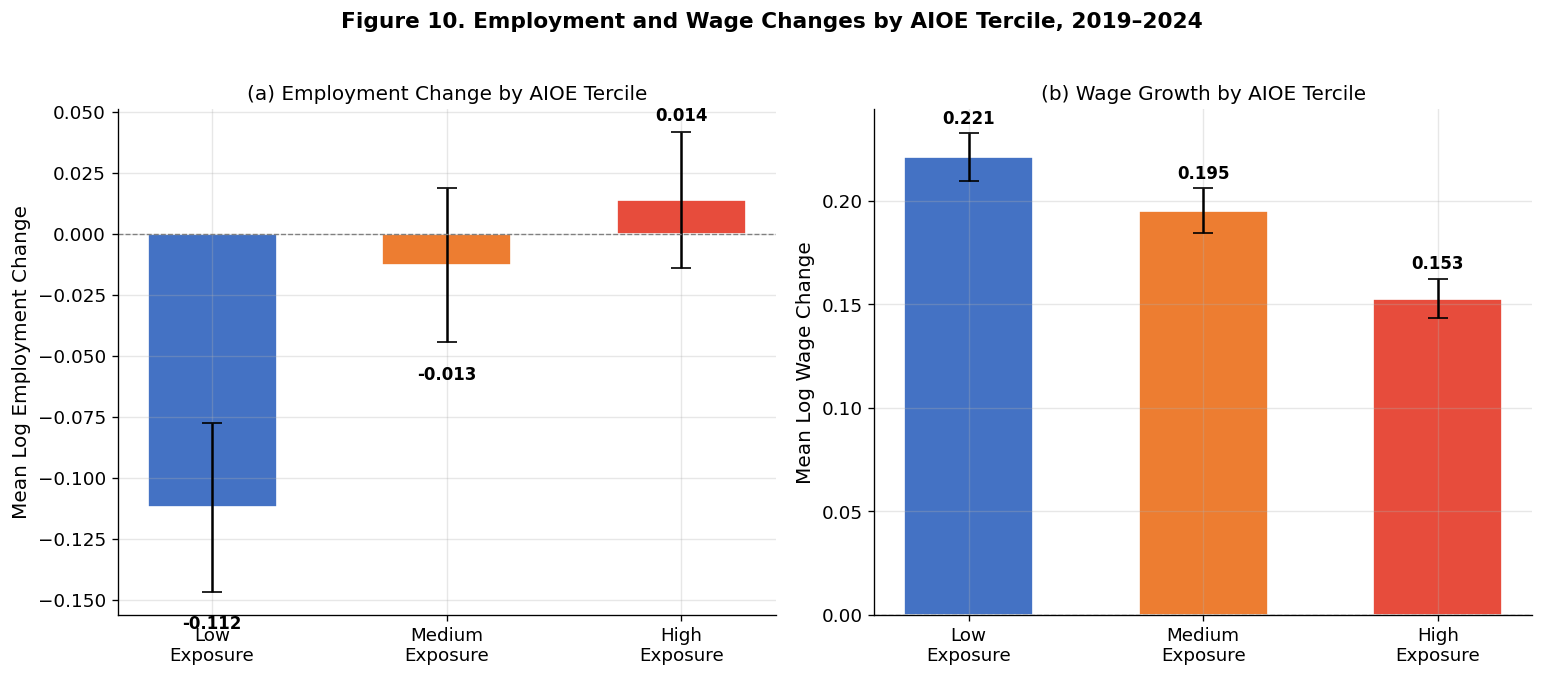

Figure 10. Employment change and wage growth by AIOE tercile, 2019–2024.

T-test: Log employment change (High vs. Low exposure):
  High mean = 0.0047, Low mean = -0.0793
  t = 4.481, p = 0.000009

T-test: Log wage change (High vs. Low exposure):
  High mean = 0.1646, Low mean = 0.2150
  t = -7.982, p = 0.000000


In [25]:
# Tercile bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
tercile_labels = ['Low\nExposure', 'Medium\nExposure', 'High\nExposure']
colors = ['#4472C4', '#ED7D31', '#E74C3C']

for ax, col, title, ylabel in [
    (axes[0], 'log_emp_change',  '(a) Employment Change by AIOE Tercile', 'Mean Log Employment Change'),
    (axes[1], 'log_wage_change', '(b) Wage Growth by AIOE Tercile',       'Mean Log Wage Change')
]:
    means = panel.groupby('aioe_tercile', observed=True)[col].mean()
    sems  = panel.groupby('aioe_tercile', observed=True)[col].sem()
    ax.bar(range(3), means, yerr=sems * 1.96, capsize=6,
           color=colors, edgecolor='white', width=0.55)
    ax.set_xticks(range(3))
    ax.set_xticklabels(tercile_labels, fontsize=11)
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=12)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    for i, (m_, s_) in enumerate(zip(means, sems)):
        offset = s_ * 1.96 + 0.005 if m_ >= 0 else -s_ * 1.96 - 0.015
        ax.text(i, m_ + offset, f'{m_:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Figure 10. Employment and Wage Changes by AIOE Tercile, 2019–2024',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/fig10_did_terciles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10. Employment change and wage growth by AIOE tercile, 2019–2024.')

# T-tests comparing high vs low exposure groups
high = panel[panel['high_exposure'] == 1]
low  = panel[panel['high_exposure'] == 0]
t_emp,  p_emp  = stats.ttest_ind(high['log_emp_change'],  low['log_emp_change'])
t_wage, p_wage = stats.ttest_ind(high['log_wage_change'], low['log_wage_change'])

print(f'\nT-test: Log employment change (High vs. Low exposure):')
print(f'  High mean = {high["log_emp_change"].mean():.4f}, Low mean = {low["log_emp_change"].mean():.4f}')
print(f'  t = {t_emp:.3f}, p = {p_emp:.6f}')
print(f'\nT-test: Log wage change (High vs. Low exposure):')
print(f'  High mean = {high["log_wage_change"].mean():.4f}, Low mean = {low["log_wage_change"].mean():.4f}')
print(f'  t = {t_wage:.3f}, p = {p_wage:.6f}')

### 5.6 Winners and Losers Among High-AIOE Occupations

Among occupations with AIOE above 0.5, employment outcomes are strikingly heterogeneous. This within-group variation underscores that exposure does not mechanically translate into displacement: some high-AIOE occupations shrink sharply while others grow rapidly.


TOP 10 EMPLOYMENT DECLINES AMONG HIGH-AIOE OCCUPATIONS (2019–2024)
--------------------------------------------------------------------------------
  Credit Authorizers, Checkers, and Clerks           AIOE=+1.44  Emp Δ= -55.2%
  Telemarketers                                      AIOE=+1.12  Emp Δ= -50.7%
  Door-To-Door Sales Workers, News and Street Vendor AIOE=+1.11  Emp Δ= -48.6%
  Switchboard Operators, Including Answering Service AIOE=+0.98  Emp Δ= -47.5%
  Insurance Appraisers, Auto Damage                  AIOE=+0.66  Emp Δ= -43.3%
  Petroleum Engineers                                AIOE=+1.25  Emp Δ= -41.8%
  Statistical Assistants                             AIOE=+1.39  Emp Δ= -39.9%
  Order Clerks                                       AIOE=+0.84  Emp Δ= -39.2%
  Proofreaders and Copy Markers                      AIOE=+1.29  Emp Δ= -33.2%
  Chemical Engineers                                 AIOE=+1.34  Emp Δ= -32.5%

TOP 10 EMPLOYMENT GAINS AMONG HIGH-AIOE OCCUPATIONS (2019–202

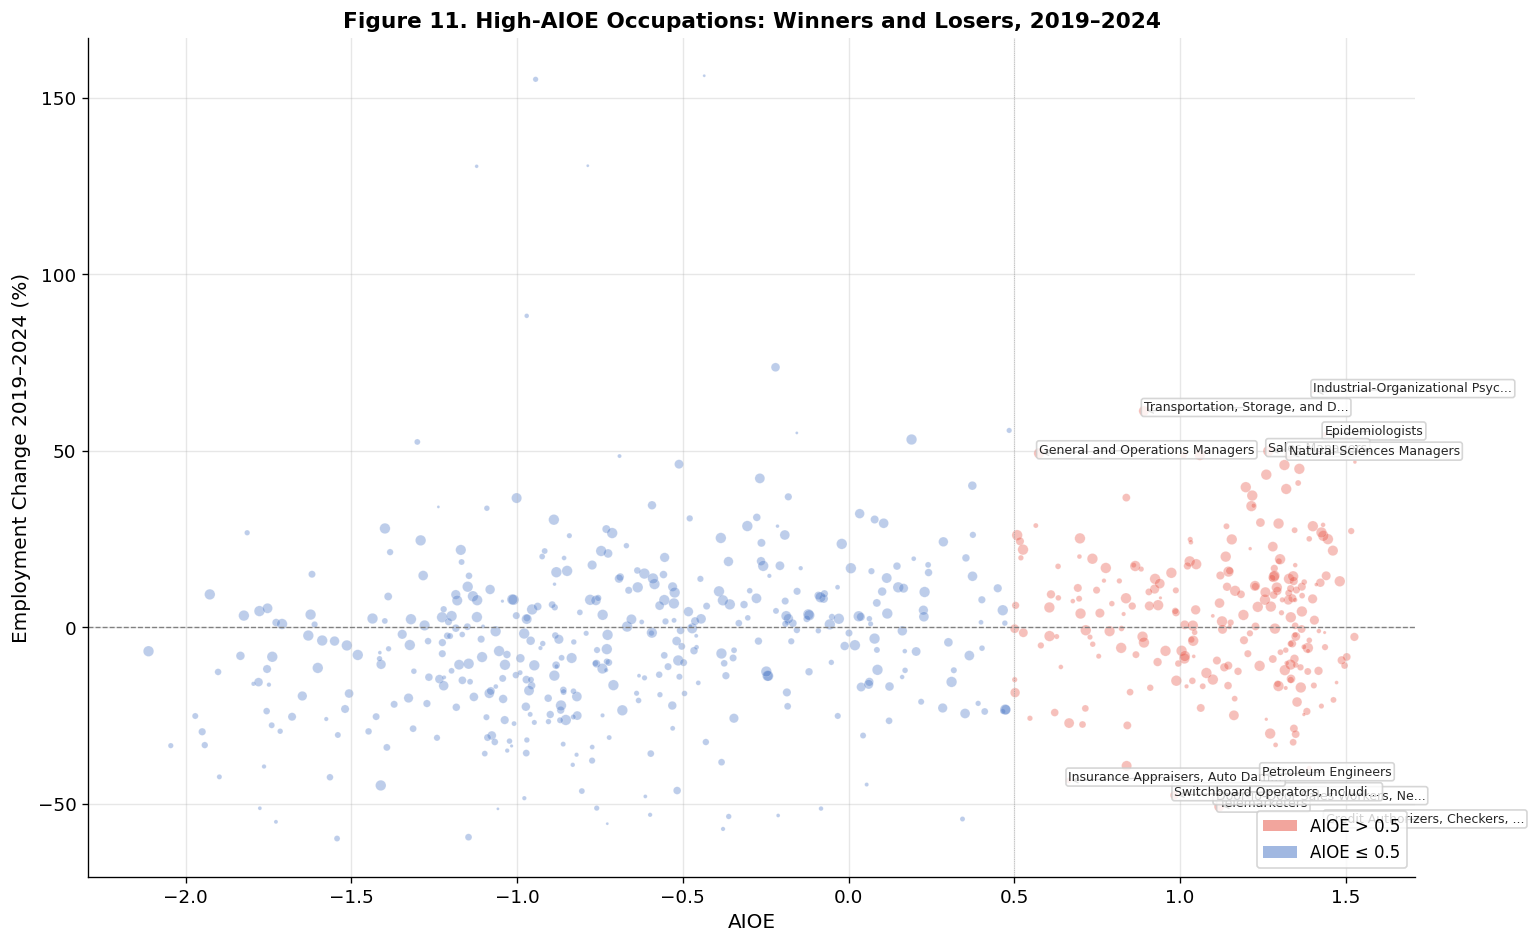

Figure 11. High-AIOE occupations: heterogeneous employment outcomes.


In [26]:
hi_aioe = panel[panel['aioe'] > 0.5]

print('TOP 10 EMPLOYMENT DECLINES AMONG HIGH-AIOE OCCUPATIONS (2019–2024)')
print('-' * 80)
for _, r in hi_aioe.nsmallest(10, 'emp_change_pct_p').iterrows():
    print(f"  {r['occupation_title_aioe'][:50]:50s} AIOE={r['aioe']:+.2f}  Emp Δ={r['emp_change_pct_p']:+6.1f}%")

print(f'\nTOP 10 EMPLOYMENT GAINS AMONG HIGH-AIOE OCCUPATIONS (2019–2024)')
print('-' * 80)
for _, r in hi_aioe.nlargest(10, 'emp_change_pct_p').iterrows():
    print(f"  {r['occupation_title_aioe'][:50]:50s} AIOE={r['aioe']:+.2f}  Emp Δ={r['emp_change_pct_p']:+6.1f}%")

# Annotated scatter
fig, ax = plt.subplots(figsize=(13, 8))
sizes = np.clip(np.sqrt(panel['tot_emp_2019']) / 10, 3, 40)
c_map = np.where(panel['aioe'] > 0.5, '#E74C3C', '#4472C4')
ax.scatter(panel['aioe'], panel['emp_change_pct_p'], s=sizes, alpha=0.35,
           c=c_map, edgecolors='white', linewidth=0.3)

notable_down = hi_aioe.nsmallest(6, 'emp_change_pct_p')
notable_up   = hi_aioe.nlargest(6,  'emp_change_pct_p')
for _, r in pd.concat([notable_down, notable_up]).iterrows():
    name = r['occupation_title_aioe']
    if len(name) > 32:
        name = name[:30] + '...'
    ax.annotate(name, (r['aioe'], r['emp_change_pct_p']), fontsize=7.5, alpha=0.85,
                arrowprops=dict(arrowstyle='->', color='#555555', lw=0.7),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='#CCCCCC', alpha=0.8))

ax.axhline(0,   color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0.5, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)
ax.set_xlabel('AIOE', fontsize=12)
ax.set_ylabel('Employment Change 2019–2024 (%)', fontsize=12)
ax.set_title('Figure 11. High-AIOE Occupations: Winners and Losers, 2019–2024',
             fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#E74C3C', alpha=0.5, label='AIOE > 0.5'),
                   Patch(facecolor='#4472C4', alpha=0.5, label='AIOE ≤ 0.5')]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig('figures/fig11_winners_losers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 11. High-AIOE occupations: heterogeneous employment outcomes.')

## 6. Demographic Vulnerability Analysis

AI Exposure by Gender Composition:
                  mean_aioe  total_emp     mean_wage    n  weighted_aioe
gender_comp                                                             
Female-dominated   0.538628   30616710  63321.764706  153       0.654873
Male-dominated    -0.708868   34604980  63651.409396  298      -0.861478
Mixed              0.511116   57404990  93750.776256  222       0.236237


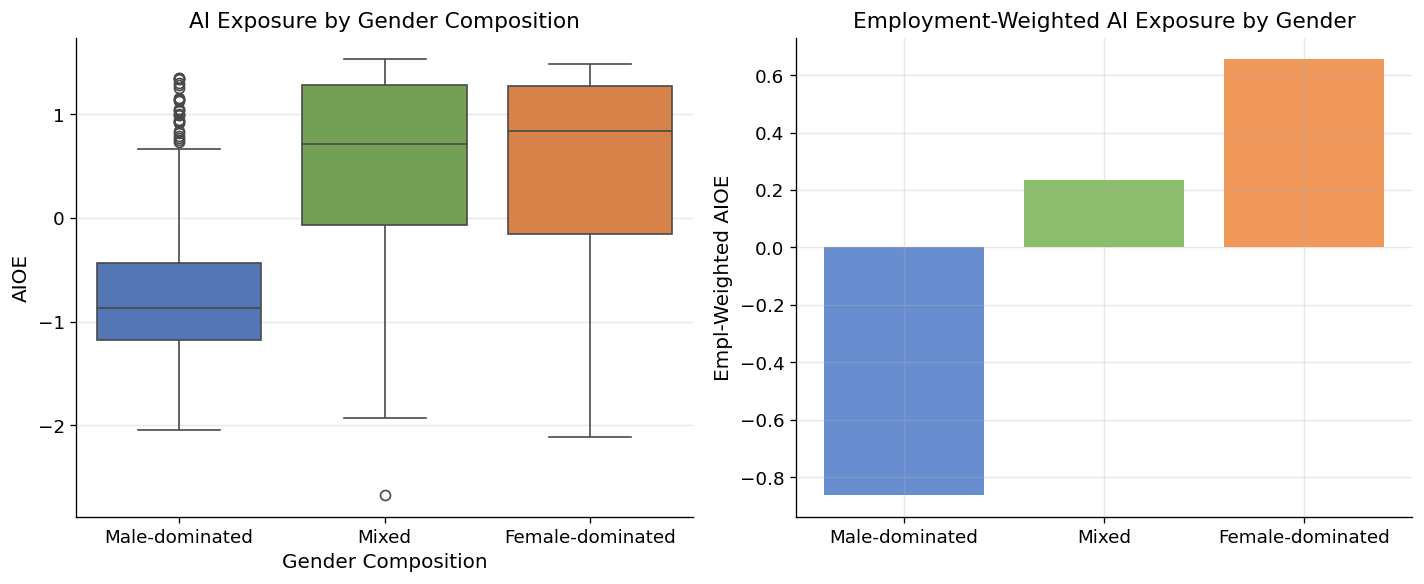


T-test (Male vs Female dominated): t = -16.051, p = 0.000000
Male-dominated mean AIOE: -0.709
Female-dominated mean AIOE: 0.539


In [27]:
female_dom = ['Healthcare Support','Office/Administrative','Education/Library',
              'Personal Care/Service','Community/Social Service']
male_dom = ['Construction/Extraction','Installation/Maintenance/Repair','Transportation/Moving',
            'Production','Farming/Fishing/Forestry','Protective Service','Architecture/Engineering']
df['gender_comp'] = df['occupation_group'].apply(lambda x: 'Female-dominated' if x in female_dom
    else 'Male-dominated' if x in male_dom else 'Mixed')

gst = df.groupby('gender_comp').agg(mean_aioe=('aioe','mean'), total_emp=('employment','sum'),
    mean_wage=('annual_mean_wage','mean'), n=('aioe','count'))
for gc in gst.index:
    g = df[df['gender_comp']==gc]
    gst.loc[gc,'weighted_aioe'] = np.average(g['aioe'], weights=g['employment'])
print("AI Exposure by Gender Composition:")
print(gst.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = ['Male-dominated','Mixed','Female-dominated']
sns.boxplot(data=df, x='gender_comp', y='aioe', order=order, palette=['#4472C4','#70AD47','#ED7D31'], ax=axes[0])
axes[0].set_xlabel('Gender Composition'); axes[0].set_ylabel('AIOE')
axes[0].set_title('AI Exposure by Gender Composition')

gs2 = gst.loc[order]
axes[1].bar(range(3), gs2['weighted_aioe'], color=['#4472C4','#70AD47','#ED7D31'], alpha=0.8)
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(order)
axes[1].set_ylabel('Empl-Weighted AIOE'); axes[1].set_title('Employment-Weighted AI Exposure by Gender')
plt.tight_layout()
plt.savefig('figures/fig14_gender_exposure.png', dpi=200, bbox_inches='tight')
plt.show()

male_a = df[df['gender_comp']=='Male-dominated']['aioe']
female_a = df[df['gender_comp']=='Female-dominated']['aioe']
t_s, t_p = stats.ttest_ind(male_a, female_a)
print(f"\nT-test (Male vs Female dominated): t = {t_s:.3f}, p = {t_p:.6f}")
print(f"Male-dominated mean AIOE: {male_a.mean():.3f}")
print(f"Female-dominated mean AIOE: {female_a.mean():.3f}")

## 7. Summary of Key Findings

In [28]:
r_logw2, _ = stats.pearsonr(vdf.dropna(subset=['log_annual_wage'])['aioe'],
                            vdf.dropna(subset=['log_annual_wage'])['log_annual_wage'])
print(f"""
{'='*60}
SUMMARY OF KEY FINDINGS
{'='*60}

Dataset: {len(df)} occupations merged from AIOE + BLS OEWS (2019+2024) + O*NET 30.2
Regression sample: {len(rdf)} occupations (with education data)
2019-2024 employment change available for: {df['emp_change_pct'].notna().sum()} occupations

1. AIOE range: [{df['aioe'].min():.3f}, {df['aioe'].max():.3f}], mean = {df['aioe'].mean():.3f}

2. Correlation: r(AIOE, log wage) = {r_logw2:.3f} (p < 0.001)

3. Regression:
   Model 1 (bivariate): R² = {m1.rsquared:.4f}
   Model 2 (with controls): R² = {m2.rsquared:.4f}
   Model 3 (interaction): R² = {m3.rsquared:.4f}

4. Gender: Female-dominated AIOE = {female_a.mean():.3f} vs Male = {male_a.mean():.3f} (p < 0.001)

5. Employment dynamics 2019-2024: slope = {slope:.2f}, r = {r_val:.3f}, p = {p_val:.3f}

6. Four risk tiers identified via K-means clustering
""")

df.to_csv('analytical_dataset.csv', index=False)
clu.to_csv('cluster_results.csv', index=False)


SUMMARY OF KEY FINDINGS

Dataset: 673 occupations merged from AIOE + BLS OEWS (2019+2024) + O*NET 30.2
Regression sample: 659 occupations (with education data)
2019-2024 employment change available for: 664 occupations

1. AIOE range: [-2.670, 1.528], mean = -0.023

2. Correlation: r(AIOE, log wage) = 0.541 (p < 0.001)

3. Regression:
   Model 1 (bivariate): R² = 0.2938
   Model 2 (with controls): R² = 0.6402
   Model 3 (interaction): R² = 0.6430

4. Gender: Female-dominated AIOE = 0.539 vs Male = -0.709 (p < 0.001)

5. Employment dynamics 2019-2024: slope = 4.55, r = 0.189, p = 0.000

6. Four risk tiers identified via K-means clustering

Analytical datasets saved.
